# EDA Condición Socioeconómica (2021)

Este notebook hace el análisis exploratorio de condiciones socioeconómicas de los 21 municipios seleccionados para el estudio conjunto de cobertura

In [2]:
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.graph_objects as go

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name == 'src' else cwd
DATA_DIR = root / 'data'
MULTI_DIR = DATA_DIR / 'multiproposito'

sys.path.append(str(root / 'src'))
from soil_poverty_analysis import (
    parse_weight_series,
    normalize_municipality,
)

In [3]:
manual_mapping = {
    'bojaca': 'Bojacá',
    'cajica': 'Cajicá',
    'chia': 'Chía',
    'facatativa': 'Facatativá',
    'fusagasuga': 'Fusagasugá',
    'gachancipa': 'Gachancipá',
    'sibate': 'Sibaté',
    'sopo': 'Sopó',
    'tocancipa': 'Tocancipá',
    'zipacon': 'Zipacón',
    'zipaquira': 'Zipaquirá',
    'rosal': 'el rosal',
    'calera': 'la calera',
}

In [4]:
def load_semicolon_csv(path, columns=None, encodings=('utf-8', 'latin1')):
    last_error = None
    for encoding in encodings:
        try:
            if columns is None:
                return pd.read_csv(path, sep=';', encoding=encoding)
            return pd.read_csv(path, sep=';', encoding=encoding, usecols=list(columns))
        except Exception as exc:
            last_error = exc
    raise last_error

In [5]:
# Load raw data
ident = load_semicolon_csv(
    MULTI_DIR / 'Identificación (Capítulo A).csv',
    columns=['DIRECTORIO', 'DPTO', 'MPIO', 'NOMBRE_ESTRATO', 'FEX_C'],
    encodings=('latin1', 'utf-8'),
)
ident['weight'] = parse_weight_series(ident['FEX_C'])
ident_cund = ident[ident['DPTO'] == 25].copy()

households_c = load_semicolon_csv(
    MULTI_DIR / 'Condiciones habitacionales del hogar (Capítulo C).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCCP1', 'NHCCP31', 'NHCCP37', 'FEX_C'],
)
households_d = load_semicolon_csv(
    MULTI_DIR / 'Servicios públicos domiciliarios y de TIC (Capítulo D).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCDP1', 'NHCDP3', 'NHCDP9', 'NHCDP15', 'NHCDP28', 'FEX_C'],
)
households_l = load_semicolon_csv(
    MULTI_DIR / 'Percepción sobre las condiciones de vida y el desempeño institucional (Capítulo L).csv',
    columns=['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCLP10', 'NHCLP11', 'NHCLP14', 'NHCLP16', 'NHCLP17', 'NHCLP18', 'NHCLP19', 'FEX_C'],
)
for df in [households_c, households_d, households_l]:
    df['weight'] = parse_weight_series(df['FEX_C'])

In [6]:
base_households = ident_cund[['DIRECTORIO', 'NOMBRE_ESTRATO']].copy()
households_c = households_c.merge(base_households, on='DIRECTORIO', how='inner')
households_d = households_d.merge(base_households, on='DIRECTORIO', how='inner')
households_l = households_l.merge(base_households, on='DIRECTORIO', how='inner')

households_d = households_d.rename(columns={'weight': 'weight_d'})
households_l = households_l.rename(columns={'weight': 'weight_l'})

households = households_c.merge(
    households_d[['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCDP1', 'NHCDP3', 'NHCDP9', 'NHCDP15', 'NHCDP28', 'NOMBRE_ESTRATO', 'weight_d']],
    on=['DIRECTORIO', 'DIRECTORIO_HOG', 'NOMBRE_ESTRATO'],
    how='left',
)
households = households.merge(
    households_l[['DIRECTORIO', 'DIRECTORIO_HOG', 'NHCLP10', 'NHCLP11', 'NHCLP14', 'NHCLP16', 'NHCLP17', 'NHCLP18', 'NHCLP19', 'NOMBRE_ESTRATO', 'weight_l']],
    on=['DIRECTORIO', 'DIRECTORIO_HOG', 'NOMBRE_ESTRATO'],
    how='left',
)
households['weight'] = households['weight'].fillna(households['weight_d']).fillna(households['weight_l'])
households = households.drop(columns=['weight_d', 'weight_l'])

In [7]:
# Create binarized variables per summary_dict.md
households['income_sufficient'] = (households['NHCLP10'] != 1).astype(float)
households['no_poor_subjective'] = (households['NHCLP11'] != 1).astype(float)
households['home_owned'] = households['NHCCP1'].isin([1, 2]).astype(float)
households['_30d_has_food'] = (households['NHCLP16'] != 1).astype(float)
households['_30d_enough_food'] = (households['NHCLP17'] != 1).astype(float)
households['_30d_healthy_food'] = (households['NHCLP18'] != 1).astype(float)
households['_30d_variety_food'] = (households['NHCLP19'] != 1).astype(float)
households['has_toilet'] = households['NHCCP31'].isin([1, 2]).astype(float)
households['has_garbage_collection'] = (households['NHCCP37'] == 1).astype(float)
households['has_aqueduct_service'] = households['NHCDP1'].isin([1, 2]).astype(float)
households['has_sewer_service'] = households['NHCDP3'].isin([1, 2]).astype(float)
households['has_electrical_service'] = households['NHCDP9'].isin([1, 2]).astype(float)
households['has_internet_service'] = households['NHCDP28'].isin([1, 2]).astype(float)

binarized_vars = {
    'income_sufficient': 'Ingresos suficientes',
    'no_poor_subjective': 'No se considera pobre',
    'home_owned': 'Vivienda propia',
    '_30d_has_food': 'Tiene alimentos (30d)',
    '_30d_enough_food': 'Suficiente comida (30d)',
    '_30d_healthy_food': 'Comida saludable (30d)',
    '_30d_variety_food': 'Variedad comida (30d)',
    'has_toilet': 'Tiene inodoro/conexión',
    'has_garbage_collection': 'Recolección basura formal',
    'has_aqueduct_service': 'Servicio acueducto',
    'has_sewer_service': 'Servicio alcantarillado',
    'has_electrical_service': 'Servicio energía eléctrica',
    'has_internet_service': 'Servicio internet',
}

In [8]:
# Get list of 21 municipalities
ident_unique = ident_cund[['NOMBRE_ESTRATO']].drop_duplicates().copy()
ident_unique['municipio_base'] = ident_unique['NOMBRE_ESTRATO'].apply(normalize_municipality)
ident_unique['municipio_base'] = ident_unique['municipio_base'].map(lambda x: manual_mapping.get(x, x))
municipios_21 = ident_unique['municipio_base'].unique()

In [9]:
# Filter to 21 municipalities
households['municipio_base'] = households['NOMBRE_ESTRATO'].apply(normalize_municipality).map(lambda x: manual_mapping.get(x, x))
households = households[households['municipio_base'].isin(municipios_21)].copy()

# Create households_raw from households (already has all raw variables)
households_raw = households.copy()

## EDA: Stacked Bar Charts for Raw Categorical Variables (Unweighted)

In [10]:
# Raw categorical variables from summary_dict.md
raw_vars = {
    'NHCLP10': 'Ingresos del hogar',
    'NHCLP11': 'Se considera pobre',
    'NHCCP1': 'Tenencia de vivienda',
    'NHCLP16': 'Preocupación por alimentos (30d)',
    'NHCLP17': 'Sin alimentos (30d)',
    'NHCLP18': 'Alimentación no saludable (30d)',
    'NHCLP19': 'Poca variedad alimentos (30d)',
    'NHCCP31': 'Servicio sanitario',
    'NHCCP37': 'Eliminación de basura',
    'NHCDP1': 'Servicio acueducto',
    'NHCDP3': 'Servicio alcantarillado',
    'NHCDP9': 'Servicio energía eléctrica',
    'NHCDP28': 'Servicio internet',
}

# Detailed categorical values from summary_dict.md
raw_var_questions = {
    'NHCLP10': 'Los ingresos de su hogar:',
    'NHCLP11': '¿Usted se considera pobre?',
    'NHCCP1': 'La vivienda ocupada por este hogar es:',
    'NHCLP16': '¿En los ÚLTIMOS 30 DÍAS, por falta de dinero u otros recursos, ¿alguna vez usted se preocupó porque los alimentos se acabaran en su hogar?',
    'NHCLP17': '¿En los ÚLTIMOS 30 DÍAS, por falta de dinero u otros recursos, ¿alguna vez en su hogar se quedaron sin alimentos?',
    'NHCLP18': '¿En los ÚLTIMOS 30 DÍAS, por falta de dinero u otros recursos, ¿alguna vez en su hogar dejaron de tener una alimentación saludable?',
    'NHCLP19': '¿En los ÚLTIMOS 30 DÍAS, por falta de dinero u otros recursos, ¿alguna vez usted o algún adulto en su hogar tuvo una alimentación basada en poca variedad de alimentos?',
    'NHCCP31': '¿Con qué tipo de servicio sanitario cuenta el hogar?',
    'NHCCP37': '¿Cómo eliminan principalmente la basura en este hogar?',
    'NHCDP1': '¿Este hogar paga por el servicio de acueducto?',
    'NHCDP3': '¿Este hogar paga por el servicio de alcantarillado?',
    'NHCDP9': '¿Este hogar paga por el servicio de energía eléctrica?',
    'NHCDP28': '¿Este hogar paga por el servicio de internet?',
}

# Detailed categorical values from summary_dict.md
raw_var_options = {
    'NHCLP10': "1: 'No alcanzan para cubrir los gastos mínimos'\n2: 'Solo alcanzan para cubrir los gastos mínimos'\n3: 'Cubren más que los gastos mínimos'",
    'NHCLP11': "1: 'Si'\n2: 'No'",
    'NHCCP1': "1: 'Propia, totalmente pagada'\n2: 'Propia, la están pagando'\n3: 'En arriendo, subarriendo'\n4: 'Leasing'\n5: 'En usufructo'\n6: 'Otra forma de tenencia (posesión sin título, ocupante de hecho, propiedad colectiva, etc)'",
    'NHCLP16': "1: 'Si'\n2: 'No'",
    'NHCLP17': "1: 'Si'\n2: 'No'",
    'NHCLP18': "1: 'Si'\n2: 'No'",
    'NHCLP19': "1: 'Si'\n2: 'No'",
    'NHCCP31': "1: 'Inodoro conectado a alcantarillado'\n2: 'Inodoro conectado a pozo séptico'\n3: 'Inodoro sin conexión'\n4: 'Letrina'\n5: 'Bajamar'\n6: 'No tiene servicio sanitario'",
    'NHCCP37': "1: 'La recogen los servicios de aseo'\n2: 'La tiran a un río, quebrada, caño o laguna'\n3: 'La tiran a un lote, patio, zanja o baldío'\n4: 'La queman'\n5: 'La entierran'\n6: 'La recoge un servicio informal (zorra, carreta, etc)'",
    'NHCDP1': "1: 'Sí'\n2: 'Sí, con el arriendo'\n3: 'No pagan'\n4: 'El hogar no cuenta con el servicio'",
    'NHCDP3': "1: 'Sí'\n2: 'Sí, con el arriendo'\n3: 'No pagan'\n4: 'El hogar no cuenta con el servicio'",
    'NHCDP9': "1: 'Sí'\n2: 'Sí, con el arriendo'\n3: 'No pagan'\n4: 'El hogar no cuenta con el servicio'",
    'NHCDP28': "1: 'Sí'\n2: 'Sí, con el arriendo'\n3: 'No pagan'",
}


In [11]:
def plot_stacked_bars_raw(df, var, title, order_by_freq=True):
    """Plot stacked bar chart for a raw categorical variable."""
    # Count frequencies per municipality and category
    crosstab = pd.crosstab(df['municipio_base'], df[var], normalize='index') * 100
    
    if order_by_freq:
        # Order categories by overall frequency (descending)
        cat_order = df[var].value_counts().index.tolist()
        crosstab = crosstab[cat_order]
    
    # Order municipalities by the lowest category frequency (ascending, from 0 onwards)
    if len(crosstab.columns) > 0:
        first_cat = crosstab.columns[0]
        muni_order = crosstab.sort_values(first_cat, ascending=True).index.tolist()
        crosstab = crosstab.loc[muni_order]
    
    ax = crosstab.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
    plt.title(f'{title} ({var}) - Unweighted', fontsize=14)
    plt.xlabel('Municipio', fontsize=12)
    plt.ylabel('Porcentaje (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # Also print the crosstab
    print(f"\n{title} ({var}) - Percentage by municipality:")
    print(crosstab.round(1))
    print()

# for var, title in raw_vars.items():
#     if var in households_raw.columns:
#         plot_stacked_bars_raw(households_raw, var, title)

## EDA: Stacked Bar Charts for Binarized Variables (Unweighted)

In [12]:
def plot_stacked_bars_bin(df, var, title, order_by_freq=True):
    """Plot stacked bar chart for a binarized variable (0 vs 1)."""
    crosstab = pd.crosstab(df['municipio_base'], df[var], normalize='index') * 100
    
    # Ensure both 0 and 1 columns exist
    for cat in [0, 1]:
        if cat not in crosstab.columns:
            crosstab[cat] = 0
    crosstab = crosstab[[0, 1]]  # Order: 0 first, then 1
    
    if order_by_freq:
        # Order municipalities by frequency of 1 (ascending, so 0 to 1)
        muni_order = crosstab.sort_values(1, ascending=True).index.tolist()
        crosstab = crosstab.loc[muni_order]
    
    ax = crosstab.plot(kind='bar', stacked=True, figsize=(14, 6), color=['#ff7f7f', '#7fff7f'])
    plt.title(f'{title} ({var}) - Unweighted', fontsize=14)
    plt.xlabel('Municipio', fontsize=12)
    plt.ylabel('Porcentaje (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(['No (0)', 'Sí (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    print(f"\n{title} ({var}) - Percentage by municipality:")
    print(crosstab.round(1))
    print()

# Prepare households_bin with municipio_base (already in households)
households_bin = households.copy()

# for var, title in binarized_vars.items():
#     plot_stacked_bars_bin(households_bin, var, title)

## EDA: Stacked Bar Charts for Raw Variables (Weighted by FEX_C)

In [13]:
def plot_stacked_bars_raw_weighted(df, var, title, weight_col='weight', order_by_freq=True):
    """Plot stacked bar chart for a raw categorical variable with weights."""
    # Weighted crosstab
    df_valid = df.dropna(subset=[var, weight_col, 'municipio_base']).copy()
    
    # Calculate weighted percentages per municipality and category
    weighted_counts = df_valid.groupby(['municipio_base', var])[weight_col].sum().unstack(fill_value=0)
    weighted_pct = weighted_counts.div(weighted_counts.sum(axis=1), axis=0) * 100
    
    if order_by_freq:
        # Order categories by overall weighted frequency
        cat_weights = df_valid.groupby(var)[weight_col].sum().sort_values(ascending=False)
        cat_order = cat_weights.index.tolist()
        weighted_pct = weighted_pct.reindex(columns=cat_order, fill_value=0)
    
    # Order municipalities by the lowest category weighted percentage (ascending, from 0 onwards)
    if len(weighted_pct.columns) > 0:
        first_cat = weighted_pct.columns[0]
        muni_order = weighted_pct.sort_values(first_cat, ascending=True).index.tolist()
        weighted_pct = weighted_pct.loc[muni_order]

    print(raw_var_questions.get(var, "Question not found"))
    print(raw_var_options.get(var, "Options not found"))
    
    ax = weighted_pct.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
    plt.title(f'{title} ({var}) - Weighted (FEX_C)', fontsize=14)
    plt.xlabel('Municipio', fontsize=12)
    plt.ylabel('Porcentaje ponderado (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Categoría', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # print(f"\n{title} ({var}) - Weighted percentage by municipality:")
    # print(weighted_pct.round(1))
    # print()

Los ingresos de su hogar:
1: 'No alcanzan para cubrir los gastos mínimos'
2: 'Solo alcanzan para cubrir los gastos mínimos'
3: 'Cubren más que los gastos mínimos'


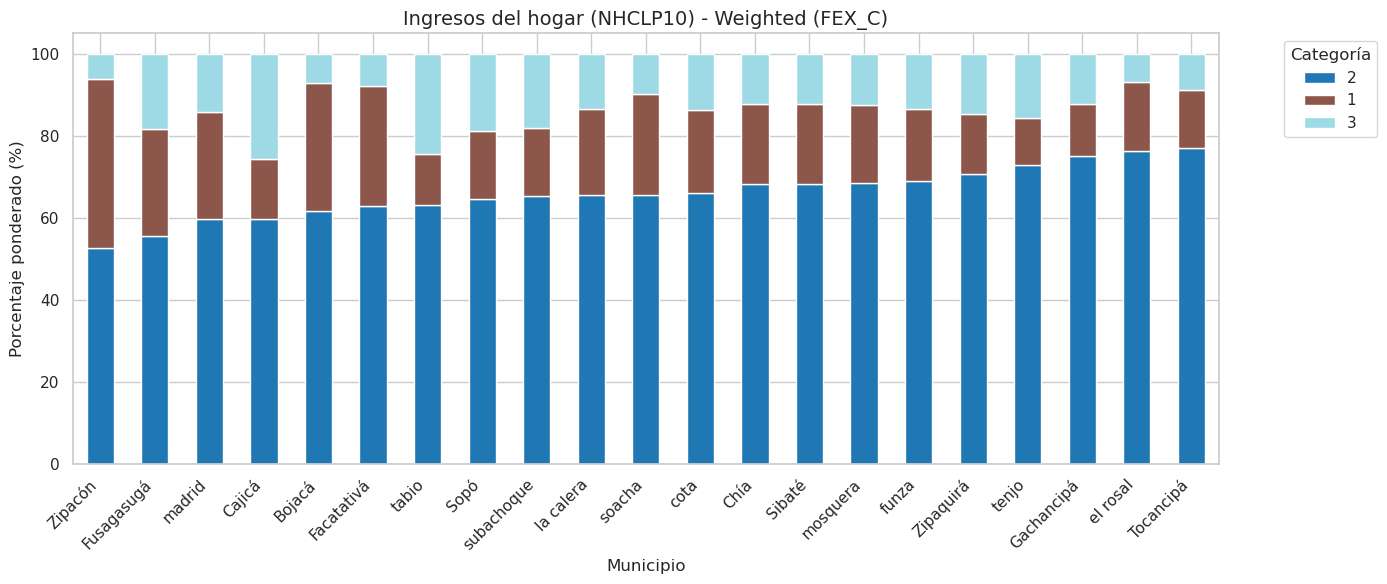

¿Usted se considera pobre?
1: 'Si'
2: 'No'


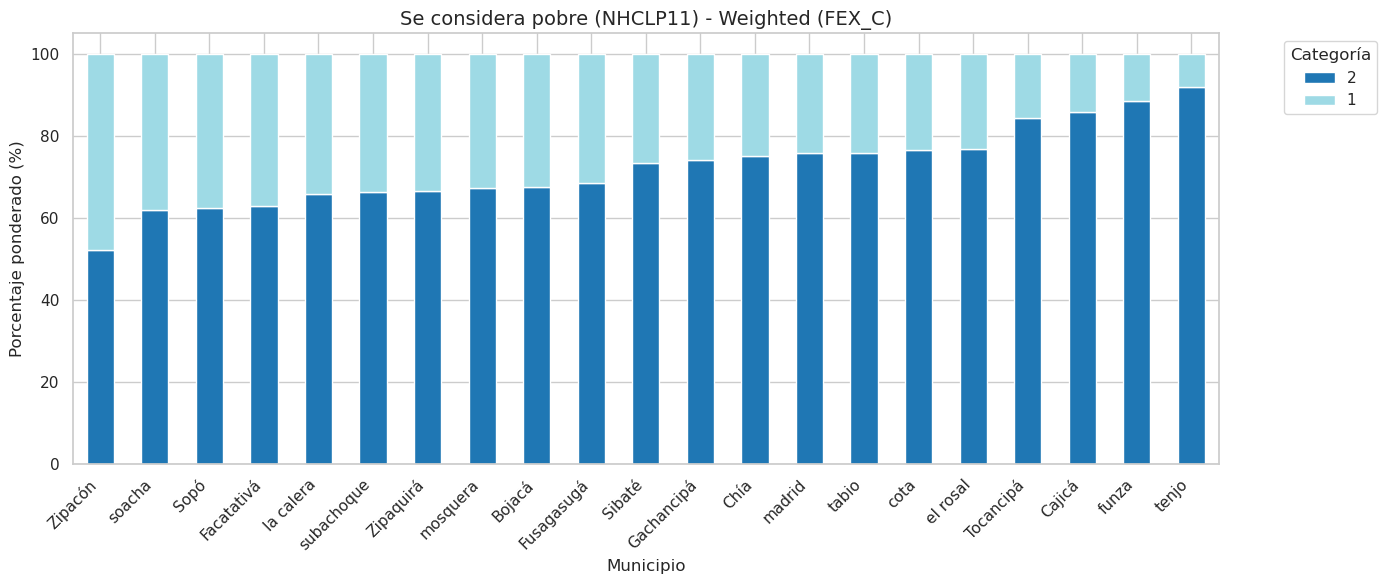

La vivienda ocupada por este hogar es:
1: 'Propia, totalmente pagada'
2: 'Propia, la están pagando'
3: 'En arriendo, subarriendo'
4: 'Leasing'
5: 'En usufructo'
6: 'Otra forma de tenencia (posesión sin título, ocupante de hecho, propiedad colectiva, etc)'


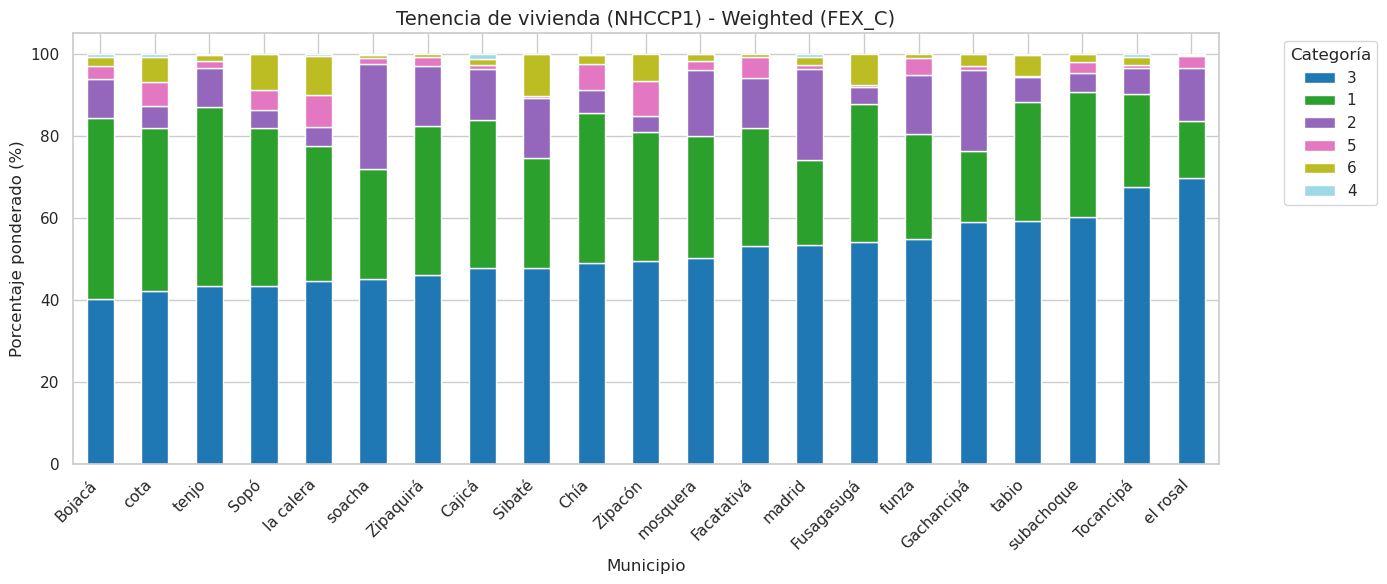

¿En los ÚLTIMOS 30 DÍAS, por falta de dinero u otros recursos, ¿alguna vez usted se preocupó porque los alimentos se acabaran en su hogar?
1: 'Si'
2: 'No'


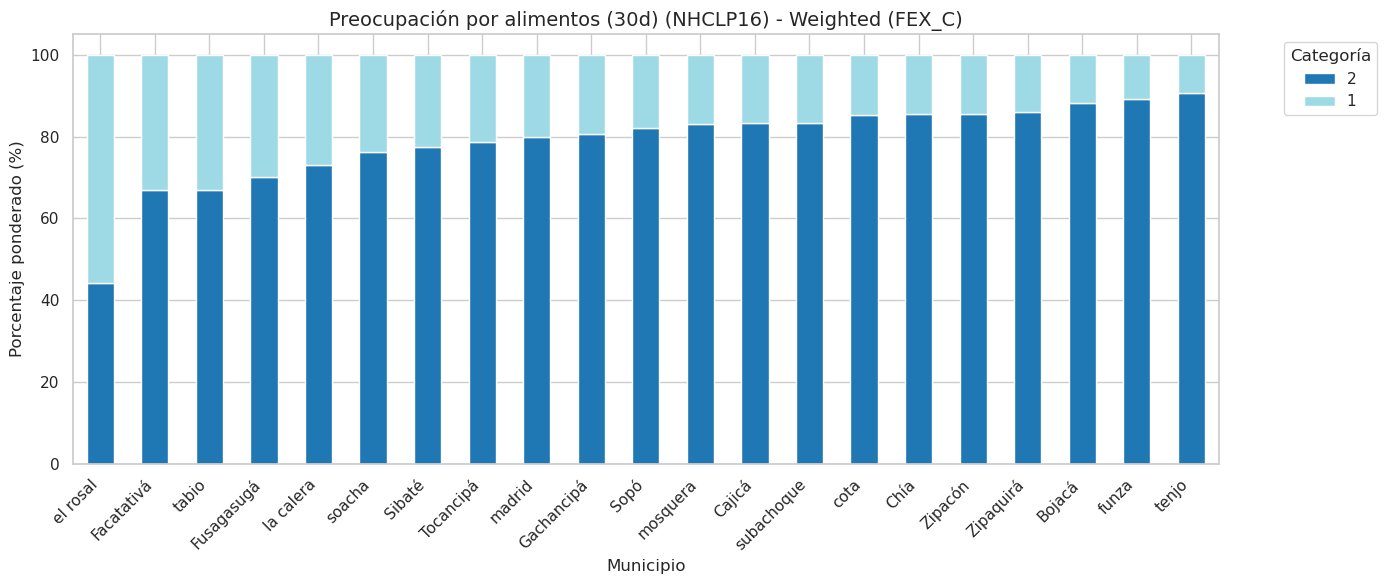

¿En los ÚLTIMOS 30 DÍAS, por falta de dinero u otros recursos, ¿alguna vez en su hogar se quedaron sin alimentos?
1: 'Si'
2: 'No'


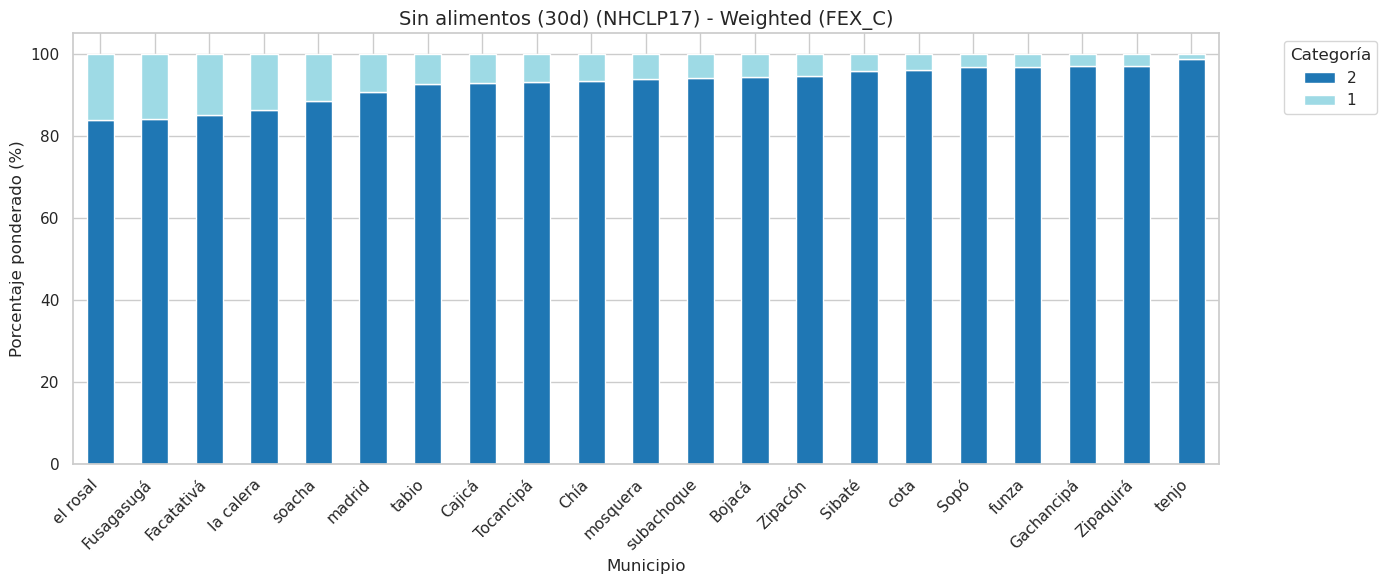

¿En los ÚLTIMOS 30 DÍAS, por falta de dinero u otros recursos, ¿alguna vez en su hogar dejaron de tener una alimentación saludable?
1: 'Si'
2: 'No'


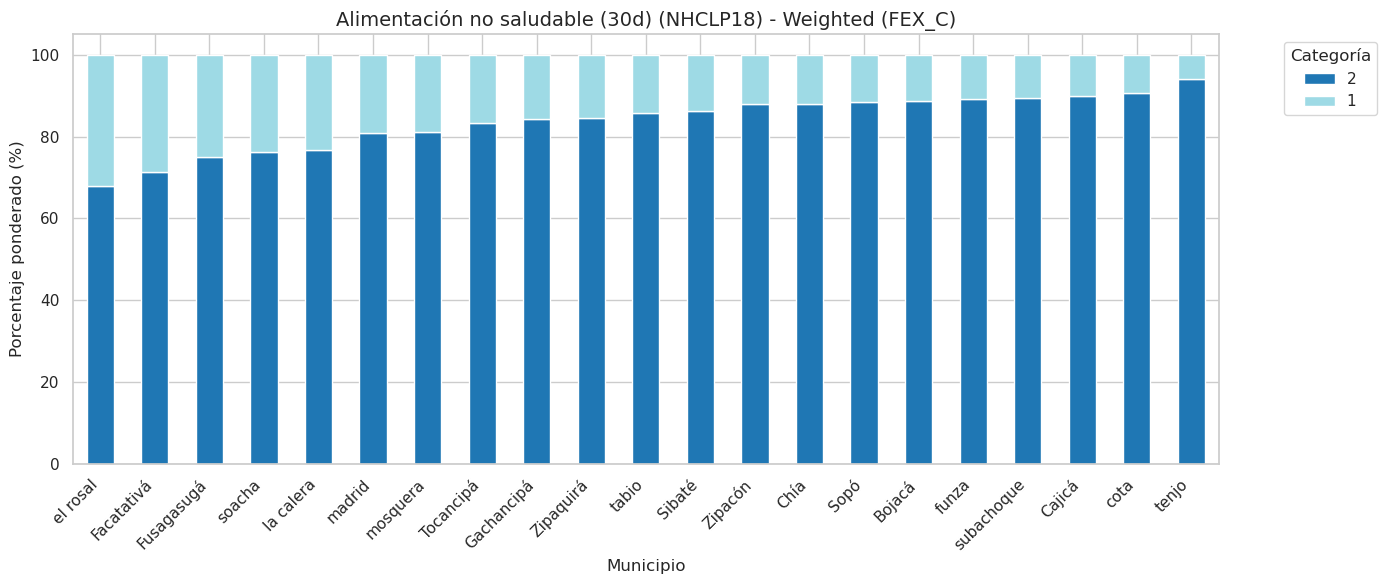

¿En los ÚLTIMOS 30 DÍAS, por falta de dinero u otros recursos, ¿alguna vez usted o algún adulto en su hogar tuvo una alimentación basada en poca variedad de alimentos?
1: 'Si'
2: 'No'


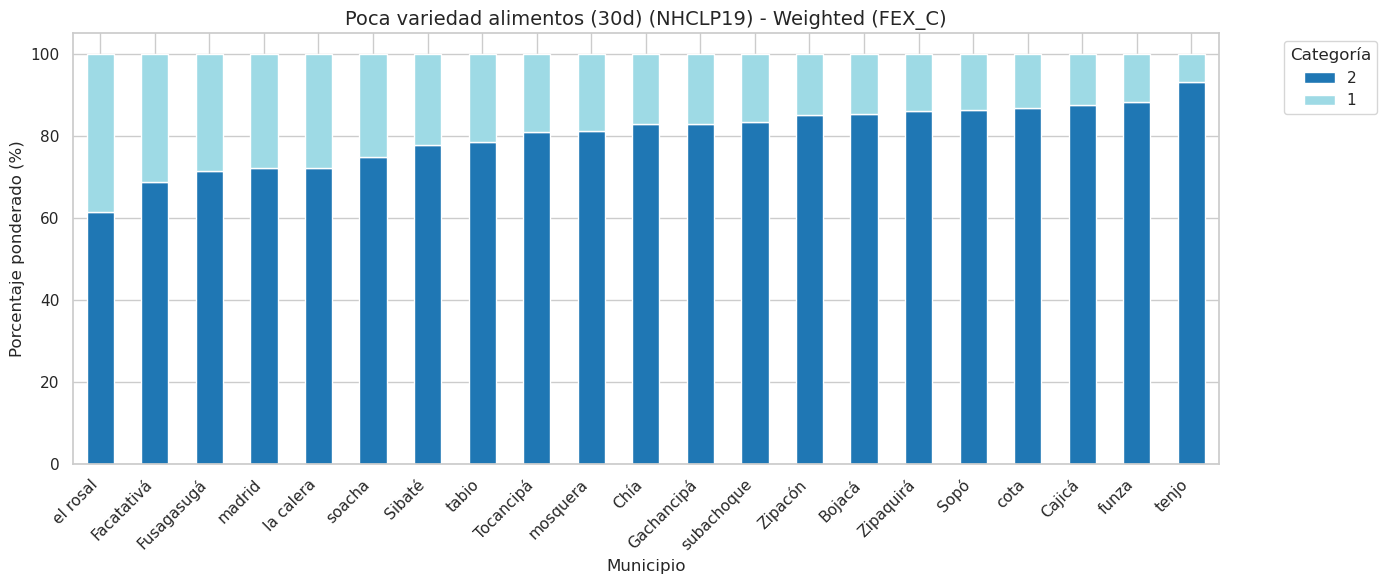

¿Con qué tipo de servicio sanitario cuenta el hogar?
1: 'Inodoro conectado a alcantarillado'
2: 'Inodoro conectado a pozo séptico'
3: 'Inodoro sin conexión'
4: 'Letrina'
5: 'Bajamar'
6: 'No tiene servicio sanitario'


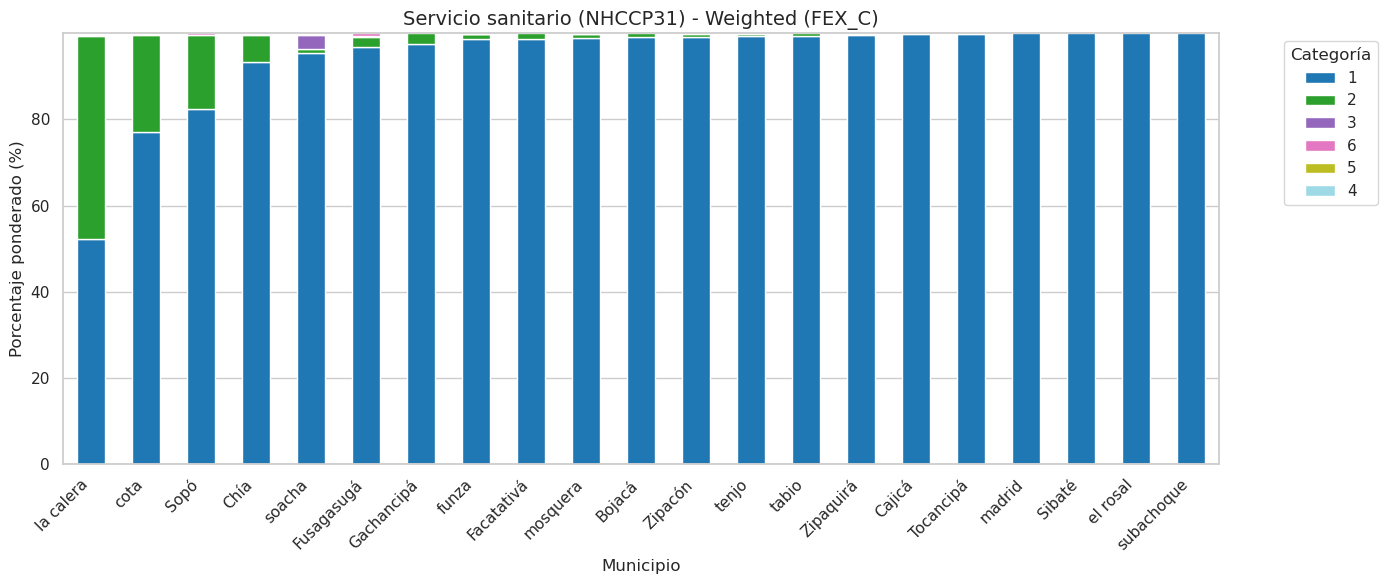

¿Cómo eliminan principalmente la basura en este hogar?
1: 'La recogen los servicios de aseo'
2: 'La tiran a un río, quebrada, caño o laguna'
3: 'La tiran a un lote, patio, zanja o baldío'
4: 'La queman'
5: 'La entierran'
6: 'La recoge un servicio informal (zorra, carreta, etc)'


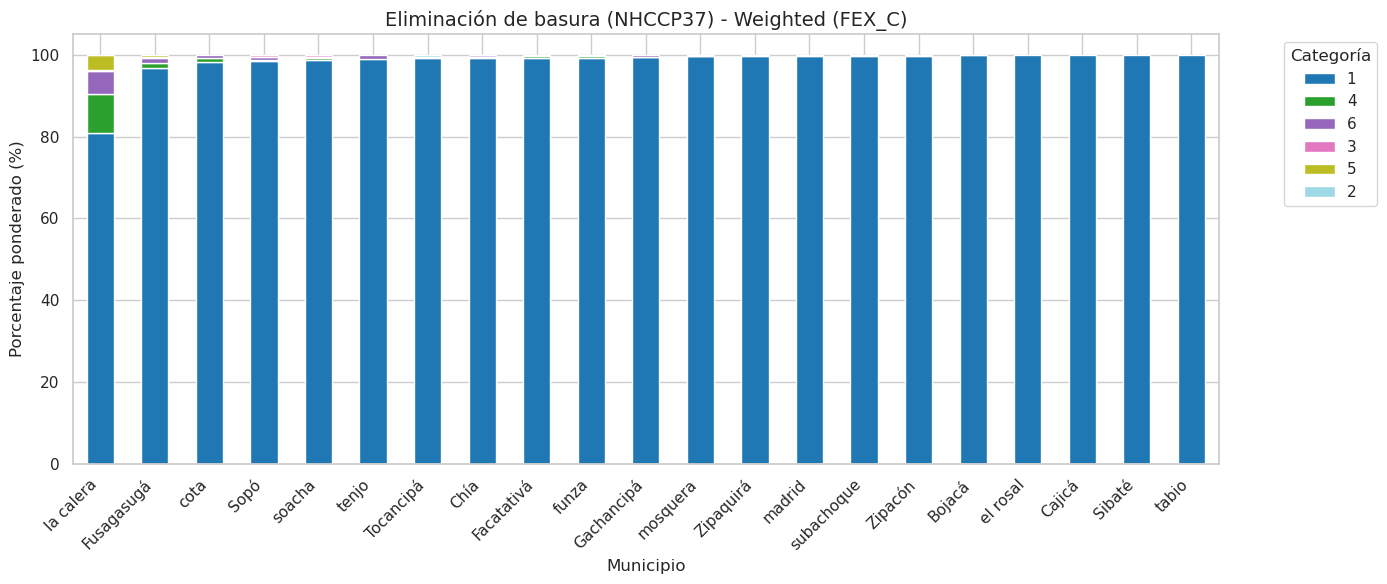

¿Este hogar paga por el servicio de acueducto?
1: 'Sí'
2: 'Sí, con el arriendo'
3: 'No pagan'
4: 'El hogar no cuenta con el servicio'


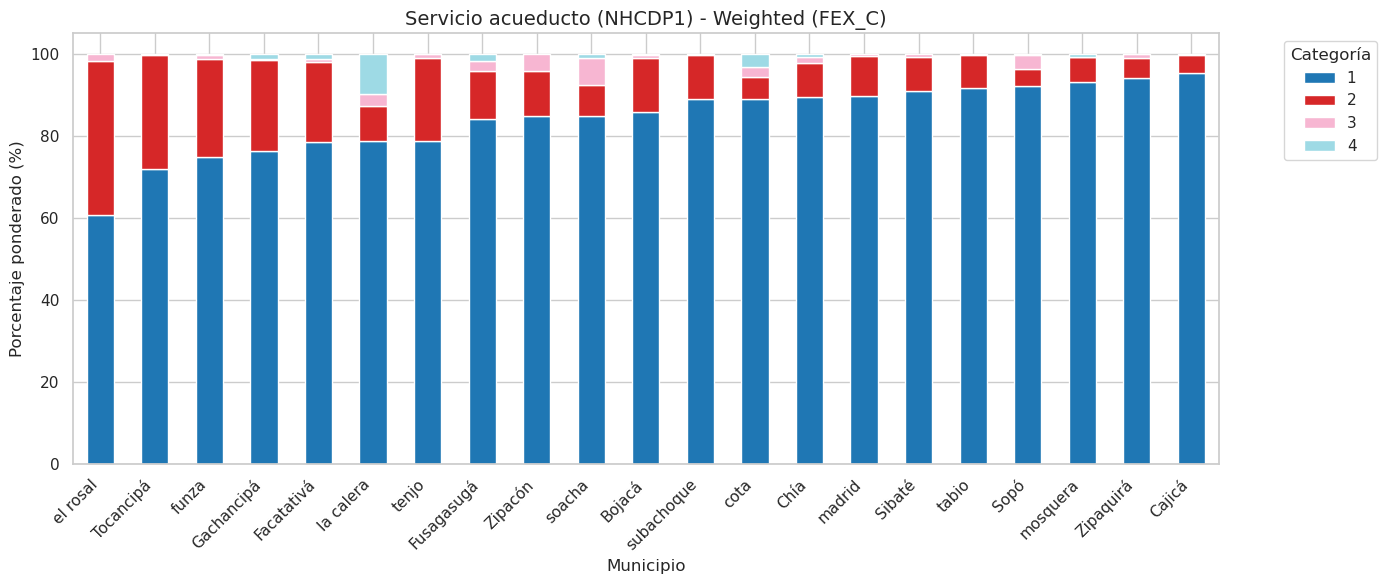

¿Este hogar paga por el servicio de alcantarillado?
1: 'Sí'
2: 'Sí, con el arriendo'
3: 'No pagan'
4: 'El hogar no cuenta con el servicio'


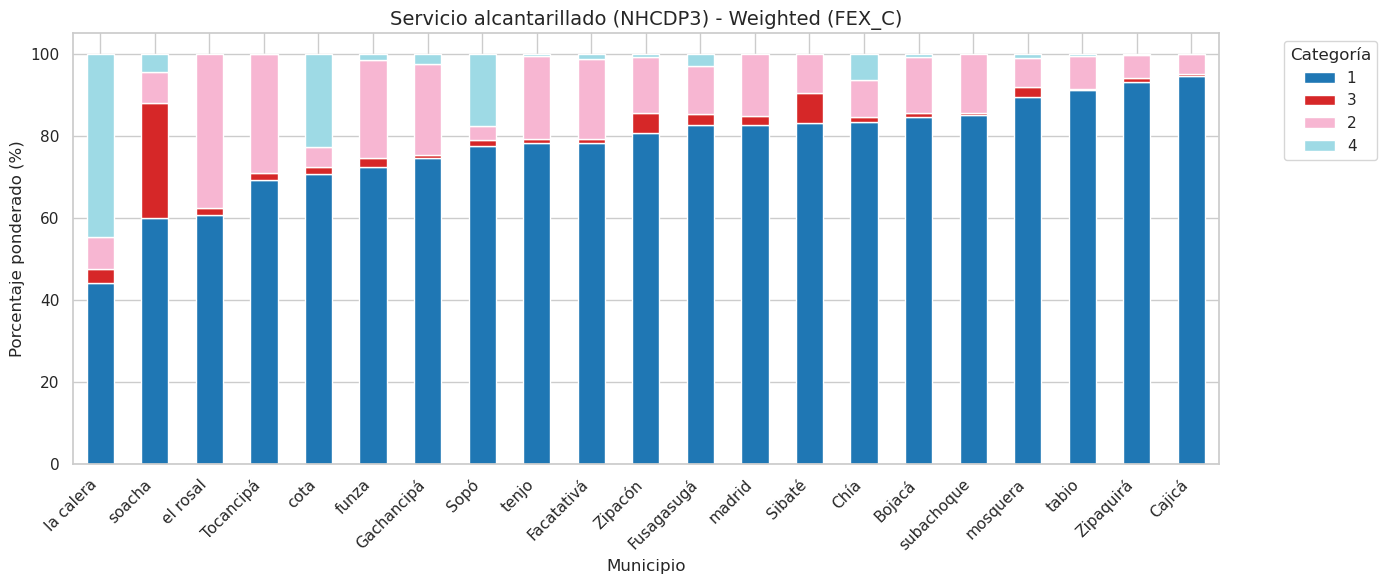

¿Este hogar paga por el servicio de energía eléctrica?
1: 'Sí'
2: 'Sí, con el arriendo'
3: 'No pagan'
4: 'El hogar no cuenta con el servicio'


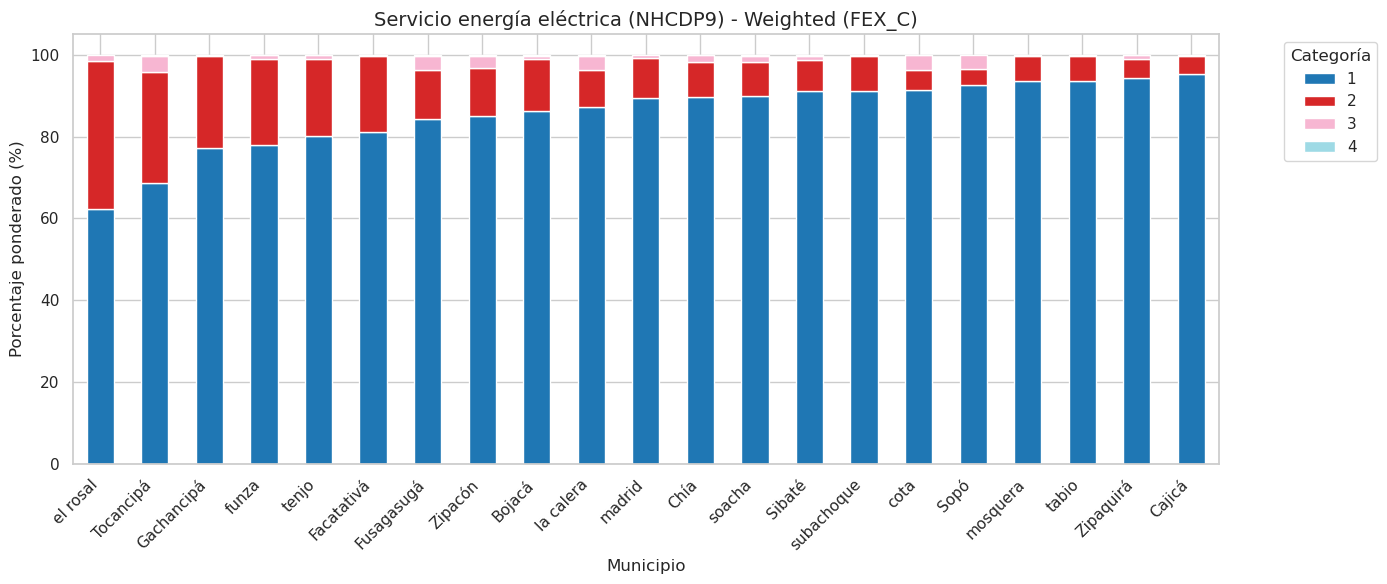

¿Este hogar paga por el servicio de internet?
1: 'Sí'
2: 'Sí, con el arriendo'
3: 'No pagan'


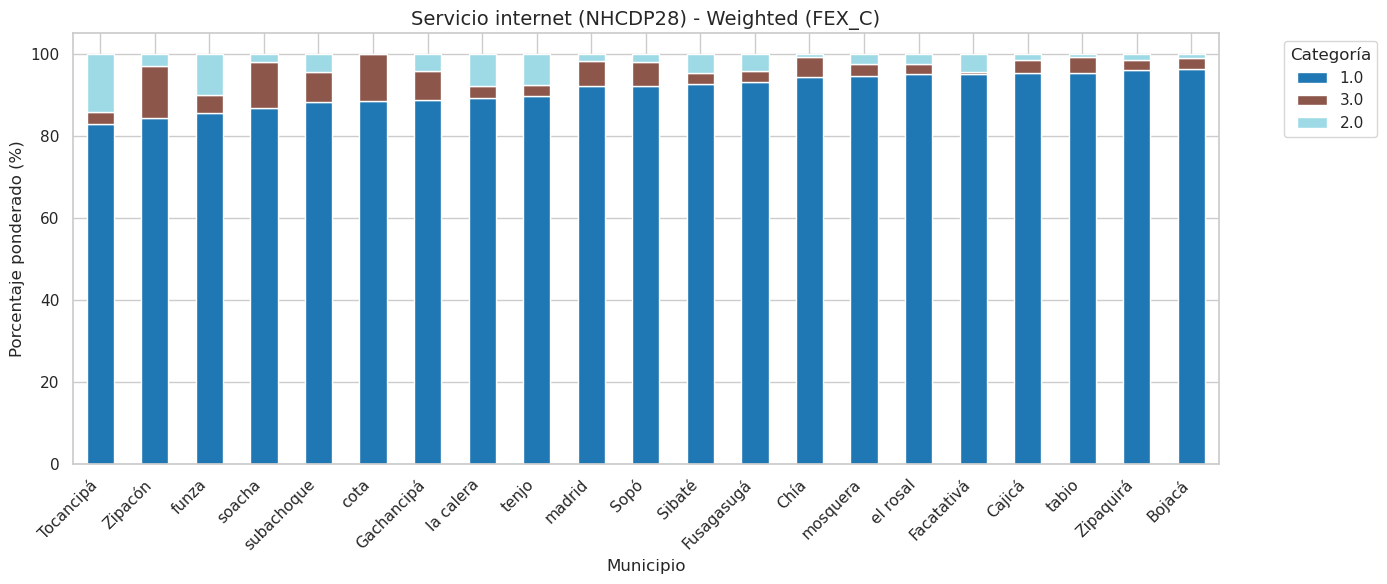

In [14]:
for var, title in raw_vars.items():
    if var in households_raw.columns:
        plot_stacked_bars_raw_weighted(households_raw, var, title)

## EDA: Stacked Bar Charts for Binarized Variables (Weighted by FEX_C)

In [15]:
def plot_stacked_bars_bin_weighted(df, var, title, weight_col='weight', order_by_freq=True):
    """Plot stacked bar chart for a binarized variable (0 vs 1) with weights."""
    df_valid = df.dropna(subset=[var, weight_col, 'municipio_base']).copy()
    
    # Weighted percentages
    weighted_counts = df_valid.groupby(['municipio_base', var])[weight_col].sum().unstack(fill_value=0)
    weighted_pct = weighted_counts.div(weighted_counts.sum(axis=1), axis=0) * 100
    
    # Ensure both 0 and 1 columns exist
    for cat in [0, 1]:
        if cat not in weighted_pct.columns:
            weighted_pct[cat] = 0
    weighted_pct = weighted_pct[[0, 1]]  # Order: 0 first, then 1
    
    if order_by_freq:
        # Order municipalities by frequency of 1 (ascending)
        muni_order = weighted_pct.sort_values(1, ascending=True).index.tolist()
        weighted_pct = weighted_pct.loc[muni_order]

    ax = weighted_pct.plot(kind='bar', stacked=True, figsize=(14, 6), color=['#ff7f7f', '#7fff7f'])
    plt.title(f'{title} ({var}) - Weighted (FEX_C)', fontsize=14)
    plt.xlabel('Municipio', fontsize=12)
    plt.ylabel('Porcentaje ponderado (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(['No (0)', 'Sí (1)'], bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
    
    # print(f"\n{title} ({var}) - Weighted percentage by municipality:")
    # print(weighted_pct.round(1))
    # print()

    return muni_order

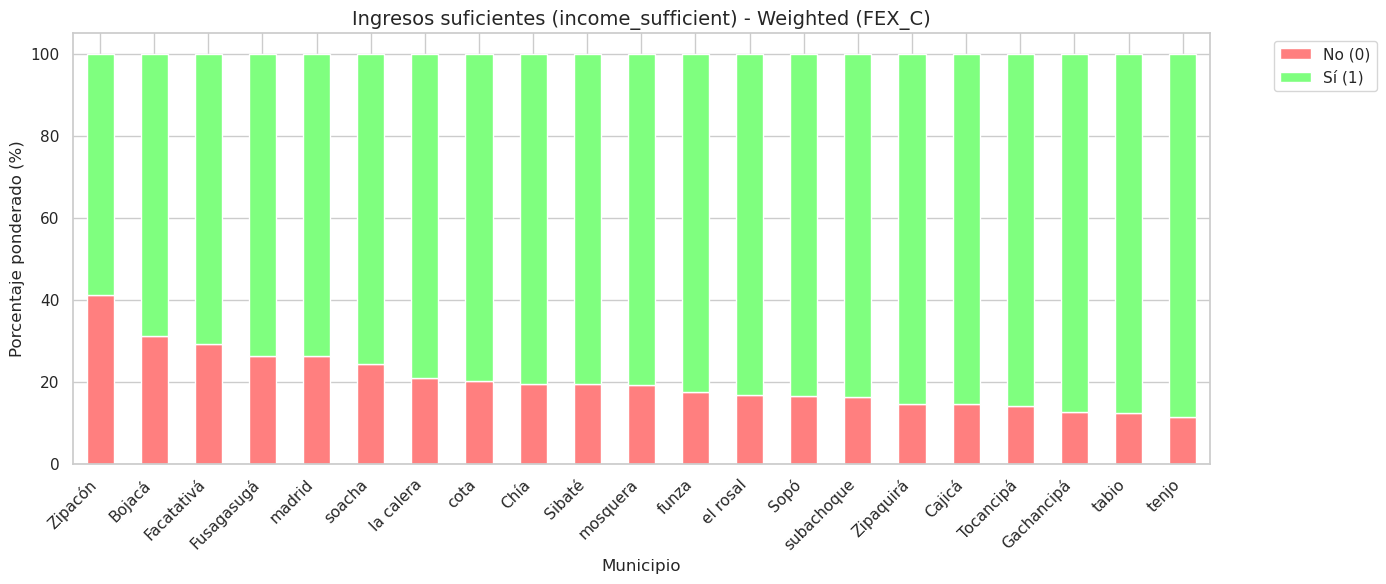

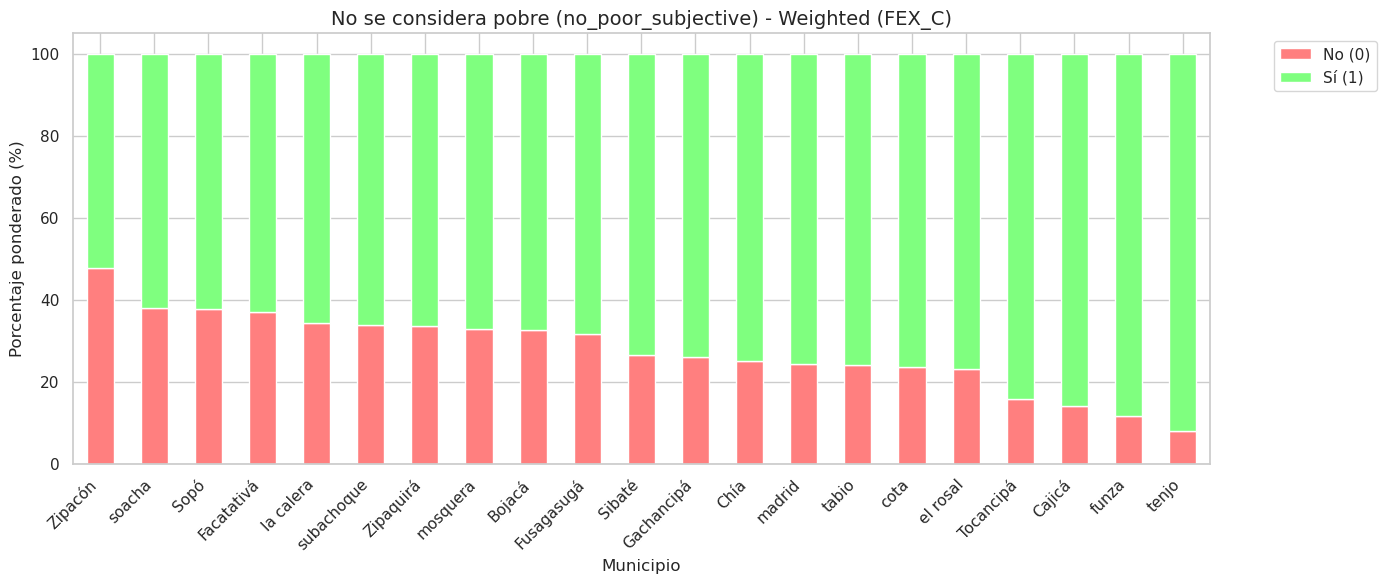

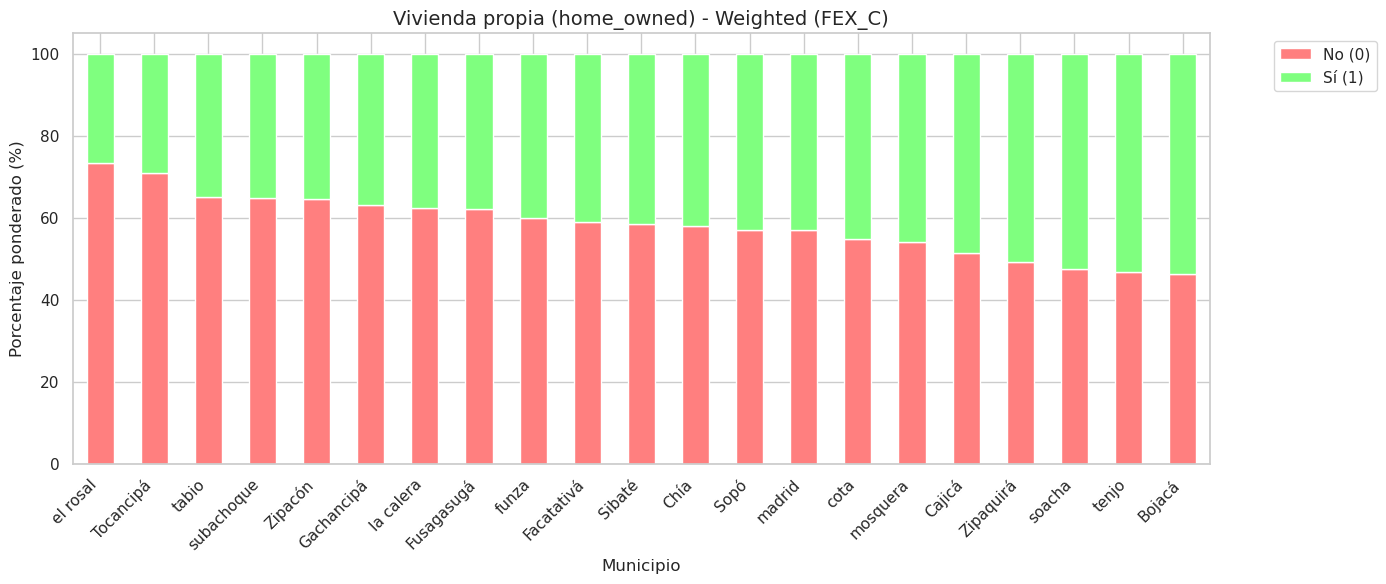

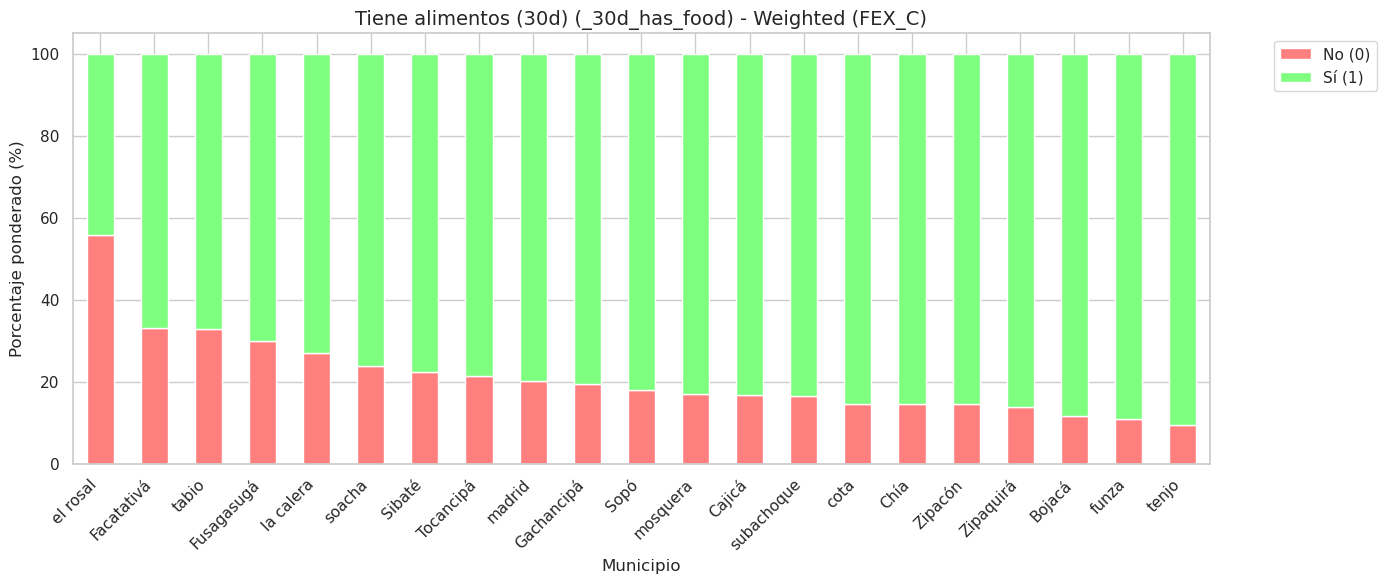

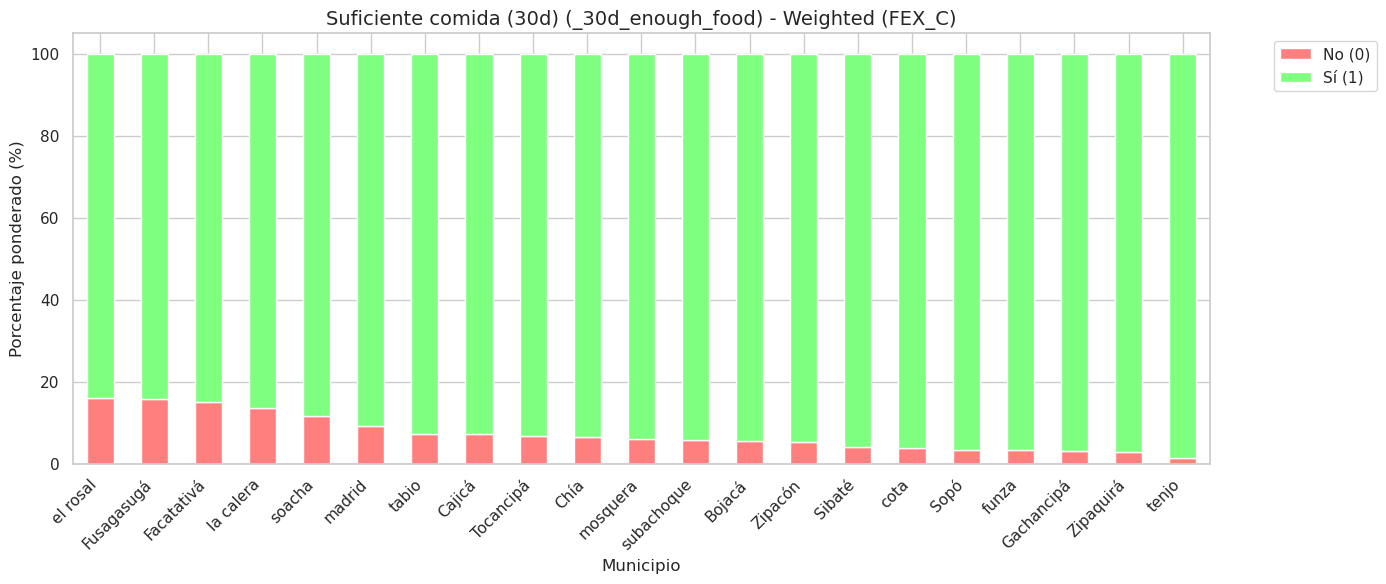

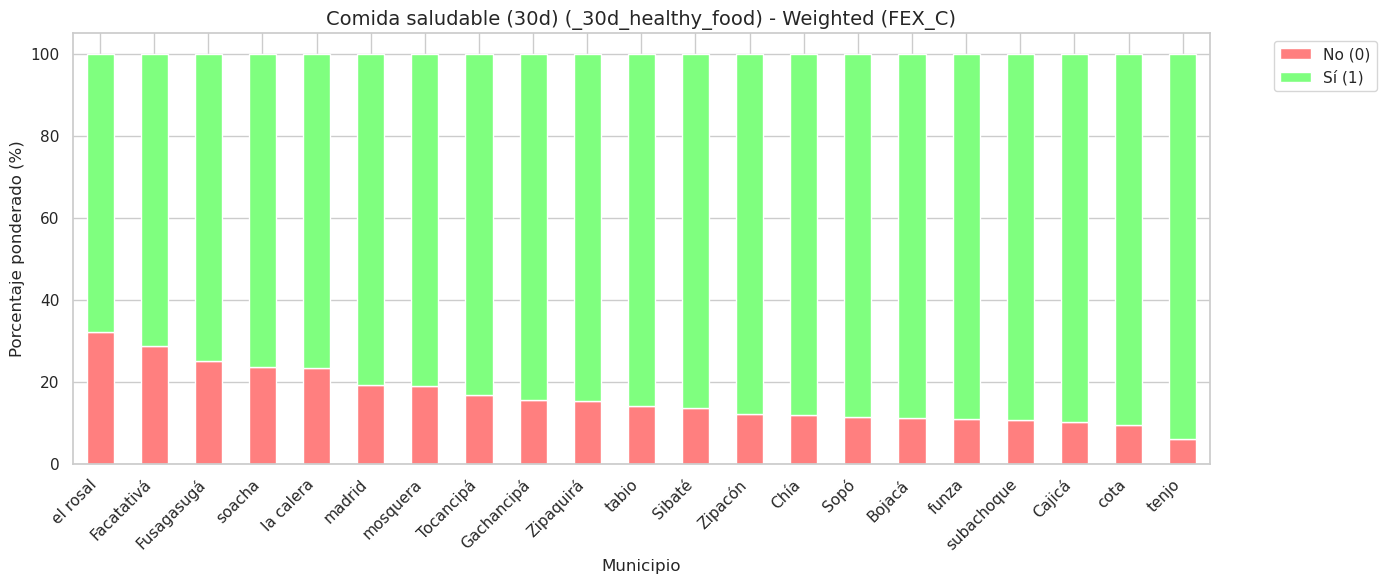

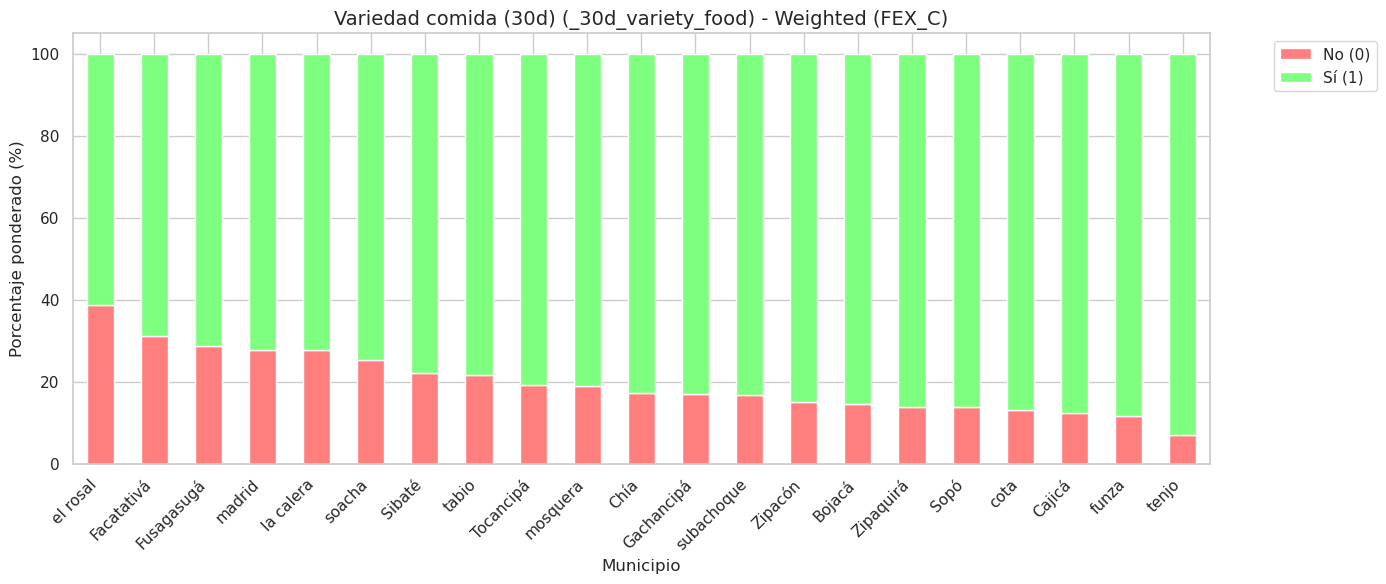

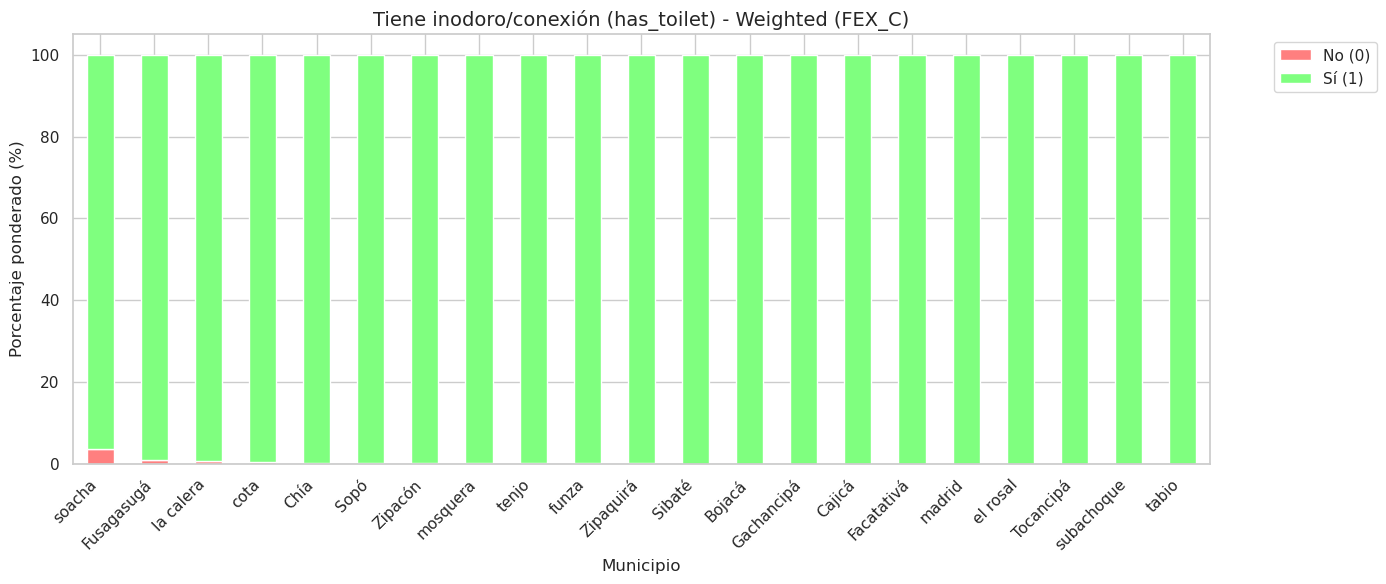

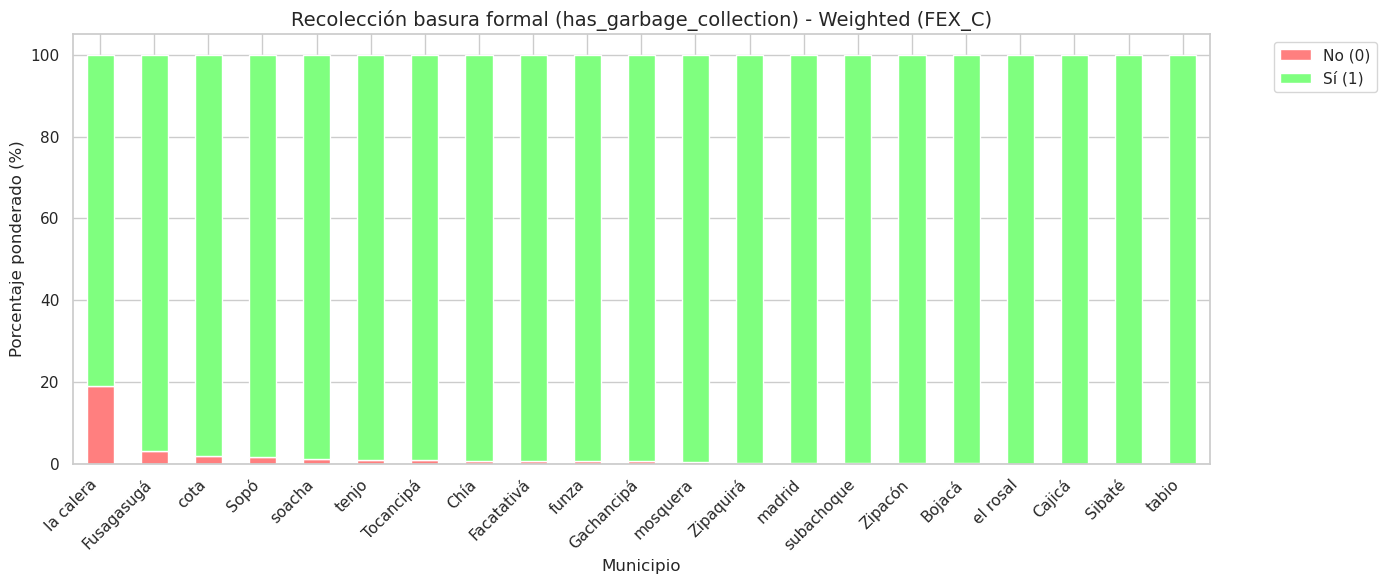

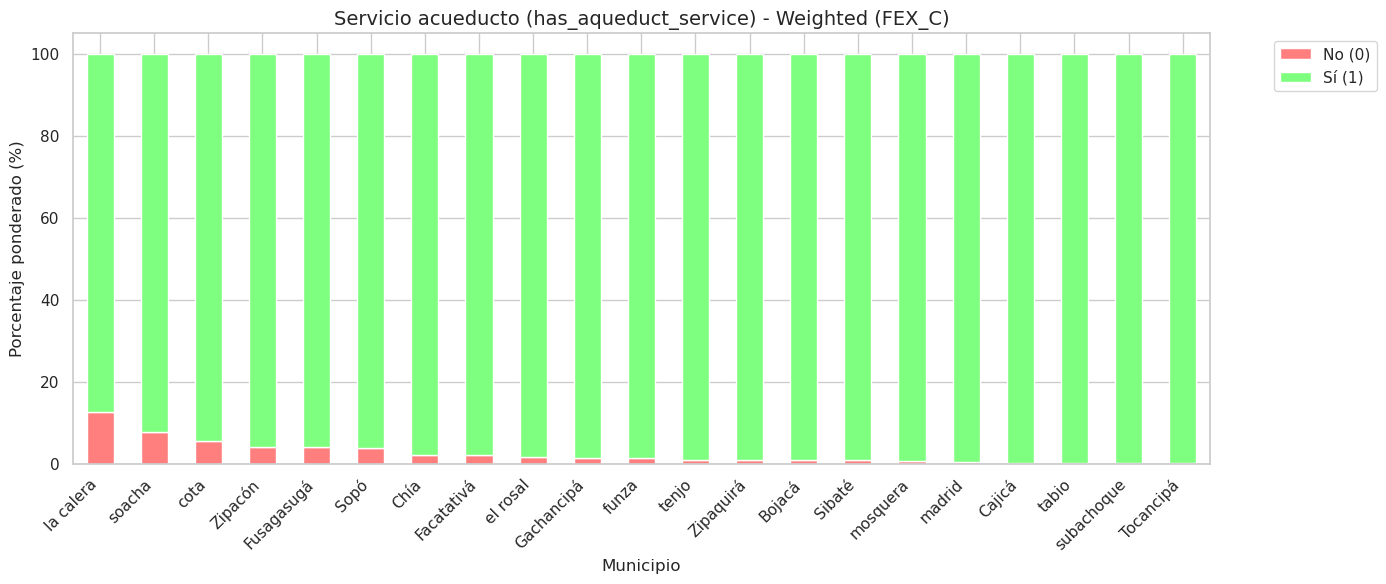

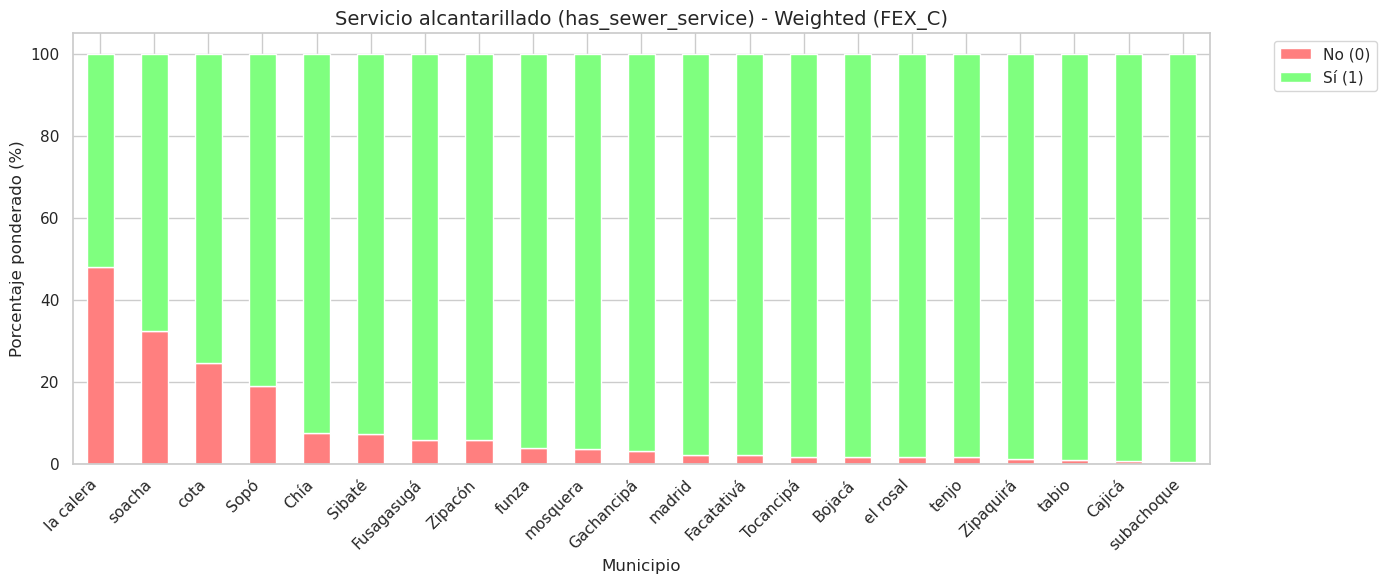

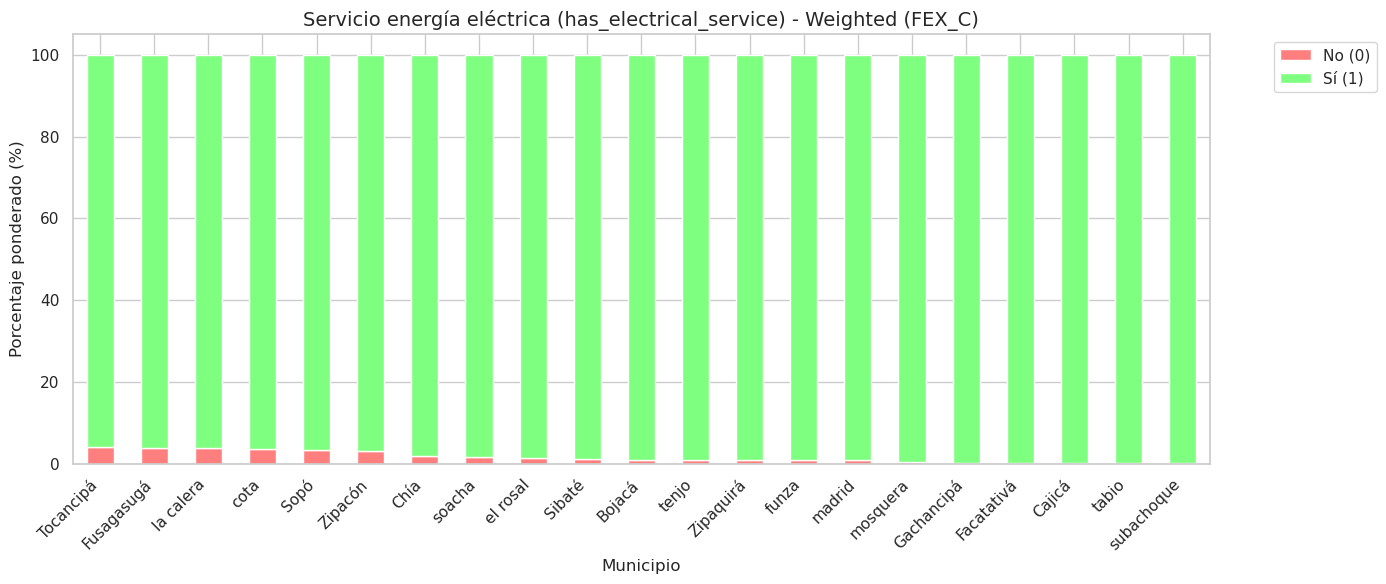

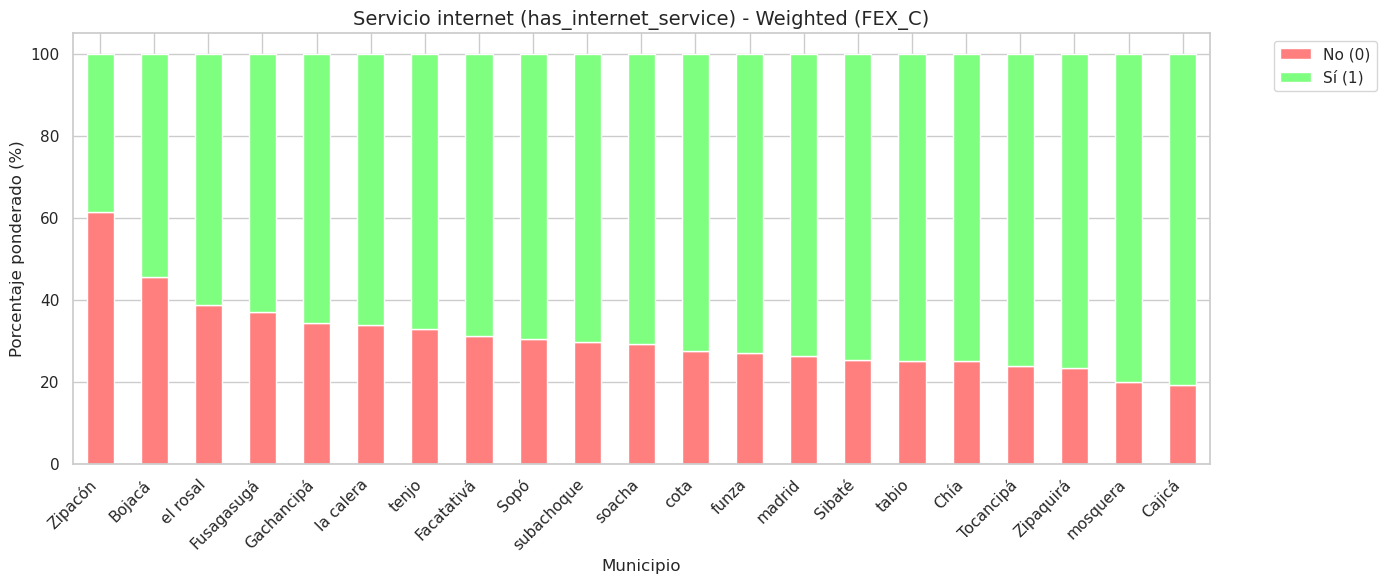

In [16]:
# Reuse households_bin (already filtered to the 21 municipalities)
order_cities = {}
for var, title in binarized_vars.items():
    order_cities[var] = plot_stacked_bars_bin_weighted(households_bin, var, title)

In [17]:
# Get all unique cities
all_cities = set()
for ranking in order_cities.values():
    all_cities.update(ranking)

n_cities = len(all_cities)

# Initialize scores
borda_scores = defaultdict(int)

# Compute Borda scores
for variable, ranking in order_cities.items():
    m = len(ranking)

    # Highest ranked gets m points, second m-1, ..., last gets 1
    for rank, city in enumerate(ranking):
        borda_scores[city] += m - rank

# Convert to DataFrame
borda_df = (
    pd.DataFrame({
        "City": borda_scores.keys(),
        "Borda Score": borda_scores.values()
    })
    .sort_values("Borda Score", ascending=False)
    .reset_index(drop=True)
)

# Add final ranking
borda_df["Overall Rank"] = borda_df.index + 1

print(borda_df)

          City  Borda Score  Overall Rank
0    la calera          233             1
1   Fusagasugá          230             2
2       soacha          209             3
3   Facatativá          188             4
4      Zipacón          179             5
5     el rosal          178             6
6         Sopó          162             7
7         Chía          152             8
8         cota          149             9
9       madrid          139            10
10      Sibaté          135            11
11   Tocancipá          134            12
12  Gachancipá          131            13
13    mosquera          129            14
14      Bojacá          119            15
15       funza          103            16
16       tabio          103            17
17  subachoque           97            18
18   Zipaquirá           94            19
19       tenjo           77            20
20      Cajicá           62            21


## EDA: Line Ranking Plot por Variable (Weighted)

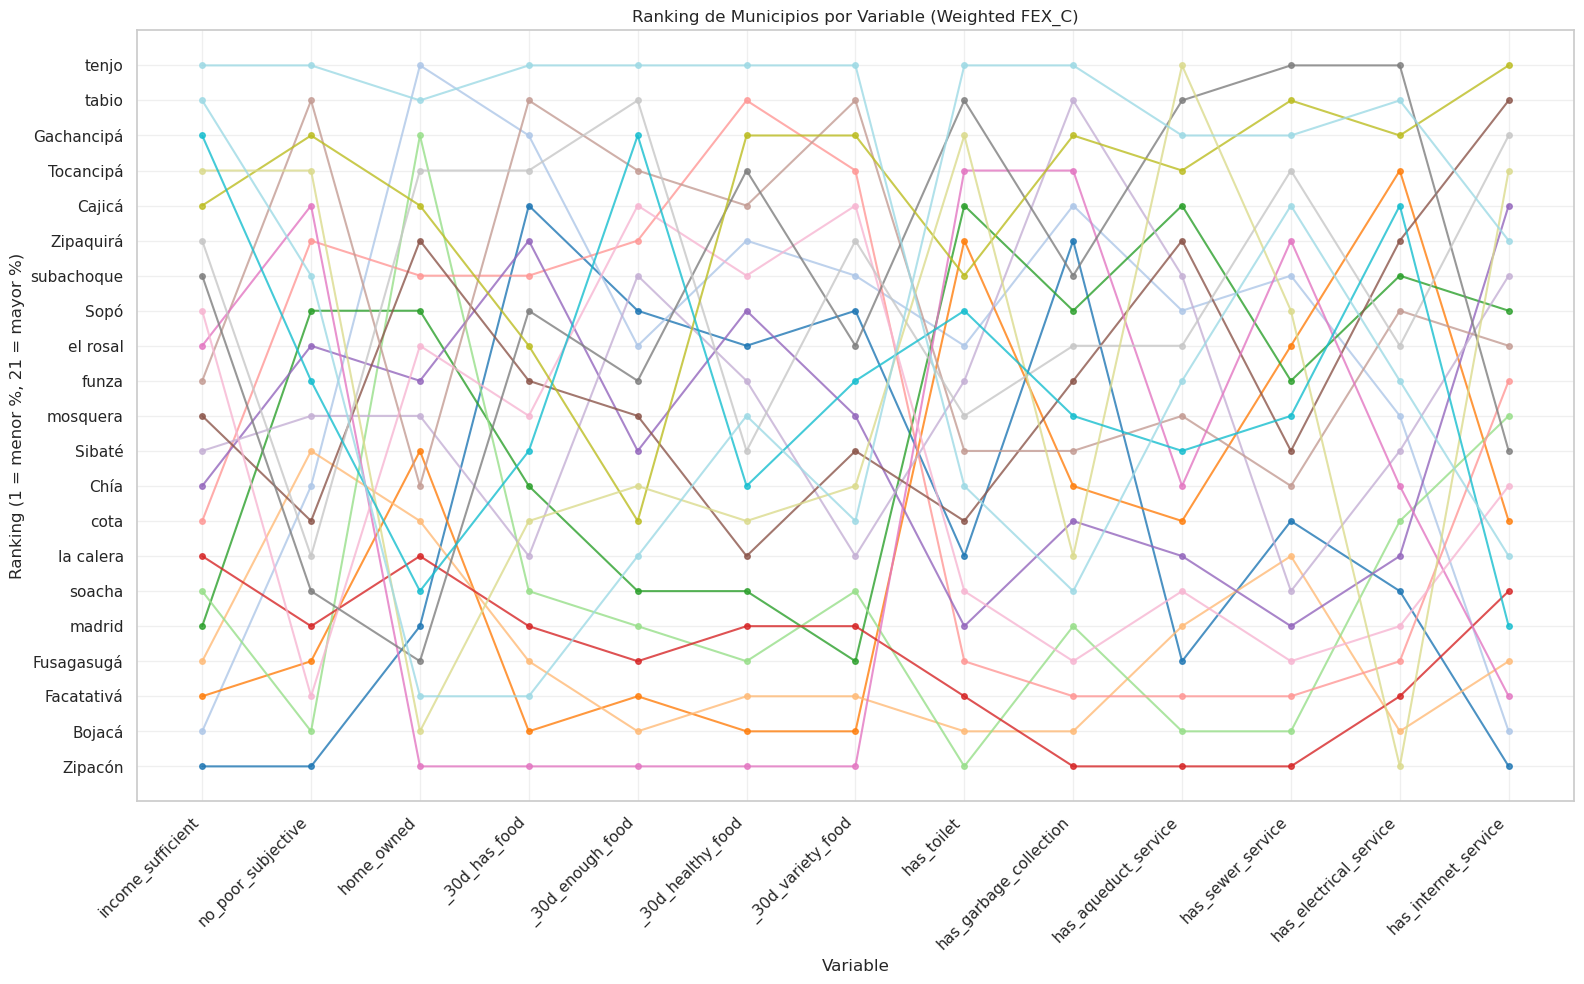

In [18]:
# Build ranking DataFrame from order_cities
rank_data = {}
for var in order_cities.keys():
    if var in order_cities:
        ranking = order_cities[var]
        rank_data[var] = {city: ranking.index(city) + 1 for city in ranking}

rank_df = pd.DataFrame(rank_data)

# Plot line ranking
plt.figure(figsize=(16, 10))
cmap = plt.cm.get_cmap('tab20', len(rank_df))

for idx, city in enumerate(rank_df.index):
    plt.plot(order_cities.keys(), rank_df.loc[city], marker='o',
             color=cmap(idx), linewidth=1.5, markersize=4, alpha=0.8)

plt.xticks(rotation=45, ha='right')
plt.yticks(range(1, len(order_cities["income_sufficient"]) + 1), order_cities["income_sufficient"])
plt.ylabel('Ranking (1 = menor %, 21 = mayor %)')
plt.xlabel('Variable')
plt.title('Ranking de Municipios por Variable (Weighted FEX_C)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [19]:
# Build ranking DataFrame from order_cities
rank_data = {}
for var in order_cities.keys():
    if var in order_cities:
        ranking = order_cities[var]
        rank_data[var] = {city: ranking.index(city) + 1 for city in ranking}

rank_df = pd.DataFrame(rank_data)
variable_order = list(rank_df.columns)

# Create Plotly figure
fig = go.Figure()

for idx, city in enumerate(rank_df.index):
    fig.add_trace(go.Scatter(
        x=variable_order,
        y=rank_df.loc[city],
        mode='lines+markers',
        name=city,
        line=dict(width=1.5),
        marker=dict(size=4),
        opacity=0.8
    ))

fig.update_layout(
    title='Ranking de Municipios por Variable (Weighted FEX_C)',
    xaxis_title='Variable',
    yaxis_title='Ranking (1 = peor, 21 = mejor)',
    yaxis=dict(
        tickmode='linear',
        tick0=1,
        dtick=1,
        range=[0.5, len(rank_df) + 0.5]
    ),
    legend=dict(
        title='Municipio',
        x=1.05,
        y=1,
        xanchor='left'
    ),
    height=700,
    width=1200,
    hovermode='x unified'
)

fig.show()

## Salario vs Pobreza

Esta sección relaciona el salario/ingreso laboral de la persona (`NPCKP23`, Capítulo K - Fuerza de trabajo) con la autopercepción de pobreza del hogar (`NHCLP11`, Capítulo L: "¿Usted se considera pobre?"). El `NPCKP23` es una variable a nivel de persona, por lo que se agrega al nivel de hogar tomando el ingreso máximo del hogar (principal percibidor de ingresos). Los códigos 98 (no sabe) y 99 (no informa) se tratan como datos faltantes.


In [20]:
# 1. Cargar NPCKP23 (Capítulo K - Fuerza de trabajo)
# Nota: este archivo presenta un bug conocido del parser C de pandas con usecols,
# por lo que se lee con engine='python'.
def load_k_labor():
    last_err = None
    for enc in ('latin1', 'utf-8'):
        try:
            return pd.read_csv(
                MULTI_DIR / 'Fuerza de trabajo (Capítulo K).csv',
                sep=';', encoding=enc, engine='python',
                usecols=['DIRECTORIO', 'DIRECTORIO_HOG', 'NPCKP23', 'FEX_C'],
            )
        except Exception as exc:
            last_err = exc
    raise last_err

labor_k = load_k_labor()

# Convertir a numérico (viene en notación científica/strings) y descartar códigos especiales
labor_k['NPCKP23_num'] = pd.to_numeric(labor_k['NPCKP23'], errors='coerce')
labor_k = labor_k[(labor_k['NPCKP23_num'].notna()) & (~labor_k['NPCKP23_num'].isin([98, 99]))]
labor_k['weight'] = parse_weight_series(labor_k['FEX_C'])

# Agregar a nivel de hogar: ingreso máximo del hogar (principal percibidor)
salary_hh = (
    labor_k.groupby(['DIRECTORIO', 'DIRECTORIO_HOG'])['NPCKP23_num']
    .max()
    .reset_index()
    .rename(columns={'NPCKP23_num': 'salary_hh'})
)
salary_hh.head()


,DIRECTORIO,DIRECTORIO_HOG,salary_hh
0,220102.0,2201021,800000.0
1,222175.0,2221751,5000000.0
2,227359.0,2273591,900000.0
3,227362.0,2273621,942000.0
4,229477.0,2294771,1000000.0


In [ ]:
# Unir con el dataframe de hogares (que ya tiene NHCLP11, municipio y filtro a 21 municipios)
households_sal = households.merge(
    salary_hh,
    on=['DIRECTORIO', 'DIRECTORIO_HOG'],
    how='inner',
)

# Variable de pobreza subjetiva (NHCLP11: 1=Si se considera pobre, 2=No)
households_sal['poor_subj'] = (households_sal['NHCLP11'] == 1).astype(float)

print(raw_var_questions.get('NHCLP11', "Question not found"))
print(raw_var_options.get('NHCLP11', "Options not found"))

print('Hogares con salario y autopercepción de pobreza:', len(households_sal))
print(households_sal[['NHCLP11', 'salary_hh']].groupby('NHCLP11')['salary_hh'].describe().round(0))

¿Usted se considera pobre?
1: 'Si'
2: 'No'
Hogares con salario y autopercepción de pobreza: 11209
          count       mean        std  min       25%        50%        75%  \
NHCLP11                                                                      
1        3085.0  1002936.0   494507.0  0.0  900000.0   908500.0  1050000.0   
2        8124.0  1672829.0  1728908.0  0.0  908500.0  1100000.0  1800000.0   

                max  
NHCLP11              
1         9000000.0  
2        40000000.0  


Correlación de Pearson (salary_hh vs NHCLP11 [1=pobre,2=no pobre]): 0.1963
Correlación de Spearman (salary_hh vs NHCLP11): 0.3012


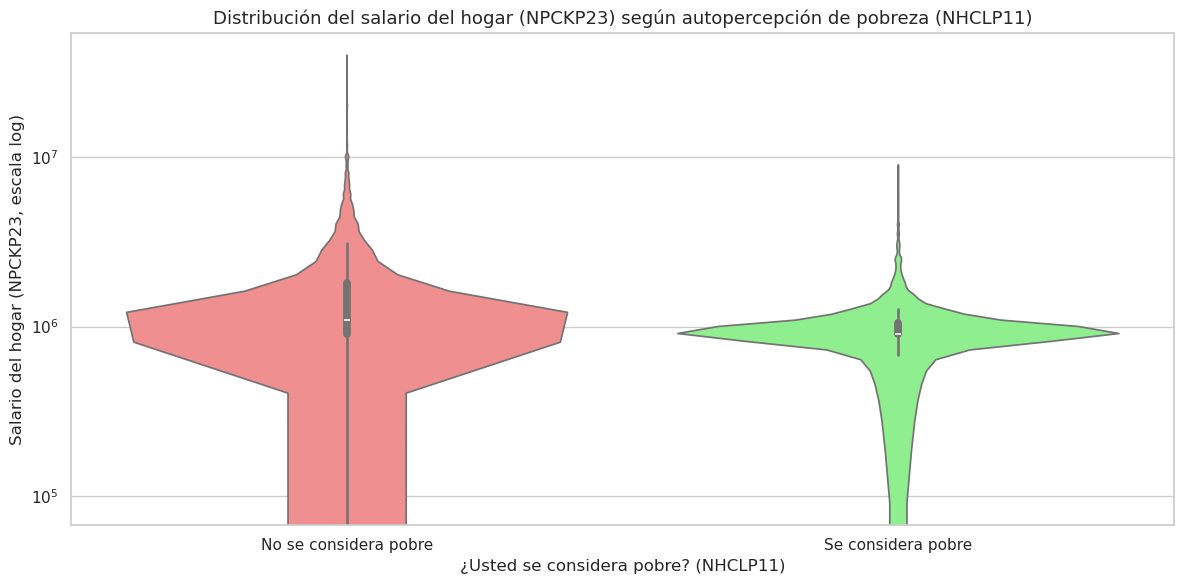


Estadísticos del salario por categoría de pobreza:
                        count       mean        std  min       25%        50%  \
categoria_pobreza                                                               
No se considera pobre  8124.0  1672829.0  1728908.0  0.0  908500.0  1100000.0   
Se considera pobre     3085.0  1002936.0   494507.0  0.0  900000.0   908500.0   

                             75%         max  
categoria_pobreza                             
No se considera pobre  1800000.0  40000000.0  
Se considera pobre     1050000.0   9000000.0  


In [22]:
def _spearman(a, b):
    """Spearman correlation, sin depender de scipy."""
    a = pd.Series(a).rank(); b = pd.Series(b).rank()
    return a.corr(b)
# 2. Correlación NPCKP23 (salary_hh) con NHCLP11 y distribución por opción de NHCLP11
valid = households_sal.dropna(subset=['salary_hh', 'NHCLP11']).copy()

# Correlación de Pearson y Spearman (NHCLP11 codificado 1=pobre, 2=no pobre)
valid['NHCLP11_num'] = valid['NHCLP11'].astype(float)
pearson_r = valid['salary_hh'].corr(valid['NHCLP11_num'], method='pearson')
spearman_r = _spearman(valid['salary_hh'], valid['NHCLP11_num'])
print(f'Correlación de Pearson (salary_hh vs NHCLP11 [1=pobre,2=no pobre]): {pearson_r:.4f}')
print(f'Correlación de Spearman (salary_hh vs NHCLP11): {spearman_r:.4f}')

# Etiquetas legibles
valid['categoria_pobreza'] = valid['NHCLP11'].map({1: 'Se considera pobre', 2: 'No se considera pobre'})

# Distribución (violin + box) del salario por categoría de pobreza
plt.figure(figsize=(12, 6))
sns.violinplot(
    data=valid, x='categoria_pobreza', y='salary_hh',
    inner='box', cut=0, palette=['#ff7f7f', '#7fff7f'],
)
plt.yscale('log')
plt.title('Distribución del salario del hogar (NPCKP23) según autopercepción de pobreza (NHCLP11)', fontsize=13)
plt.xlabel('¿Usted se considera pobre? (NHCLP11)')
plt.ylabel('Salario del hogar (NPCKP23, escala log)')
plt.tight_layout()
plt.show()

# Estadísticos por grupo
print('\nEstadísticos del salario por categoría de pobreza:')
print(valid.groupby('categoria_pobreza')['salary_hh'].describe().round(0))


In [23]:
# 3. Misma correlación/distribución pero separada por municipio
valid_m = valid.dropna(subset=['municipio_base']).copy()

# Correlación por municipio
corr_by_muni = (
    valid_m.groupby('municipio_base')
    .apply(lambda g: _spearman(g['salary_hh'], g['NHCLP11_num']) if len(g) > 5 else np.nan, include_groups=False)
    .dropna()
    .sort_values()
)
print('Correlación de Spearman (salary vs pobreza) por municipio:')
print(corr_by_muni.round(3))


Correlación de Spearman (salary vs pobreza) por municipio:
municipio_base
Bojacá        0.158
Gachancipá    0.161
tabio         0.208
el rosal      0.218
Tocancipá     0.225
tenjo         0.234
subachoque    0.235
Facatativá    0.257
madrid        0.261
Chía          0.269
Cajicá        0.275
la calera     0.289
mosquera      0.290
cota          0.311
Zipacón       0.324
Sopó          0.354
funza         0.356
soacha        0.358
Sibaté        0.366
Fusagasugá    0.434
Zipaquirá     0.498
dtype: float64


In [37]:
valid_m

,DIRECTORIO,DIRECTORIO_HOG,NHCCP1,NHCCP31,NHCCP37,FEX_C,weight,NOMBRE_ESTRATO,NHCDP1,NHCDP3,...,has_garbage_collection,has_aqueduct_service,has_sewer_service,has_electrical_service,has_internet_service,municipio_base,salary_hh,poor_subj,NHCLP11_num,categoria_pobreza
0,1468512.0,14685121,3,1,1,"9,83072291244878",9.830723,El Rosal cabecera,2,2,...,1.0,1.0,1.0,1.0,1.0,el rosal,908000.0,0.0,2.0,No se considera pobre
1,1469782.0,14697821,1,1,1,"27,5668695464937",27.566870,Cajicá cabecera,1,1,...,1.0,1.0,1.0,1.0,1.0,Cajicá,950000.0,0.0,2.0,No se considera pobre
2,1471307.0,14713071,3,1,1,"9,52473868807827",9.524739,El Rosal cabecera,1,1,...,1.0,1.0,1.0,1.0,1.0,el rosal,908000.0,0.0,2.0,No se considera pobre
3,1697773.0,16977731,1,1,1,"54,9674449217114",54.967445,Facatativá cabecera,1,1,...,1.0,1.0,1.0,1.0,1.0,Facatativá,950000.0,1.0,1.0,Se considera pobre
4,1699248.0,16992481,2,1,1,"10,1668199341938",10.166820,Tocancipá cabecera,1,1,...,1.0,1.0,1.0,1.0,1.0,Tocancipá,2100000.0,0.0,2.0,No se considera pobre
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11204,1163234.0,11632341,2,1,1,"21,9574215944282",21.957422,Cajicá cabecera,1,1,...,1.0,1.0,1.0,1.0,1.0,Cajicá,1300000.0,0.0,2.0,No se considera pobre
11205,1163235.0,11632351,1,1,1,"12,8700639546",12.870064,Cota cabecera,1,1,...,1.0,1.0,1.0,1.0,1.0,cota,3000000.0,0.0,2.0,No se considera pobre
11206,1163239.0,11632391,3,2,1,"8,72809835283784",8.728098,Cota resto,1,4,...,1.0,1.0,0.0,1.0,1.0,cota,1500000.0,0.0,2.0,No se considera pobre
11207,1163241.0,11632411,5,1,1,"19,0299909555221",19.029991,Cota cabecera,1,1,...,1.0,1.0,1.0,1.0,1.0,cota,900000.0,0.0,2.0,No se considera pobre


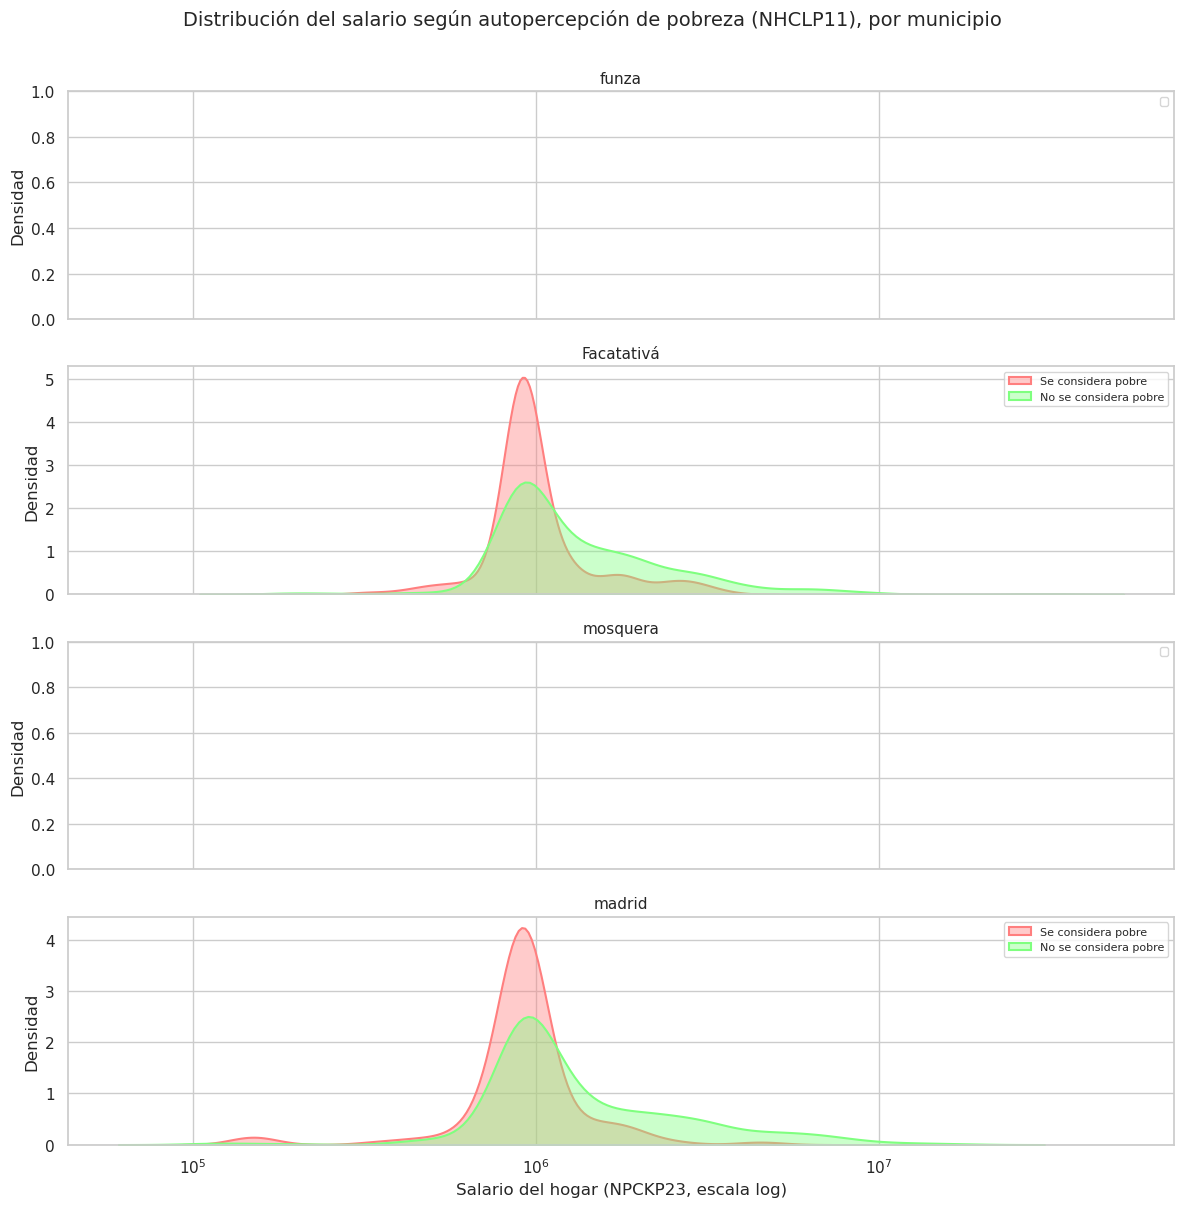

In [39]:
# Distribución (KDE con transparencia) del salario por municipio, superponiendo ambas categorías de NHCLP11
order_muni = ['funza', 'Facatativá', 'mosquera', 'madrid']

fig, axes = plt.subplots(nrows=len(order_muni), ncols=1, figsize=(12, 3 * len(order_muni)), sharex=True)
if len(order_muni) == 1:
    axes = [axes]

for ax, muni in zip(axes, order_muni):
    sub = valid_m[valid_m['municipio_base'] == muni]
    for cat, color, label in [(1, '#ff7f7f', 'Se considera pobre'),
                              (2, '#7fff7f', 'No se considera pobre')]:
        vals = sub.loc[sub['NHCLP11'] == cat, 'salary_hh']
        if len(vals) > 1:
            sns.kdeplot(
                data=vals, ax=ax, fill=True, alpha=0.4, color=color,
                linewidth=1.5, label=label, log_scale=True,
            )
    ax.set_title(muni, fontsize=11)
    ax.set_ylabel('Densidad')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Salario del hogar (NPCKP23, escala log)')
fig.suptitle('Distribución del salario según autopercepción de pobreza (NHCLP11), por municipio', y=1.005, fontsize=14)
plt.tight_layout()
plt.show()
